SHAP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
SEED = 42

import os
import random

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_PATH = "/kaggle/input/datasets/cvbnqq/data-1/train_2.csv"
# DATA_PATH = "train_2.csv"


df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(5))

shape: (485082, 24)
columns: ['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии', 'РТО']


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74209339.11


In [4]:
df.columns = df.columns.str.replace(',', '', regex=False)
df.columns

Index(['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия категориальный',
       'Торговая площадь категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший в час', 'Трафик авто в час',
       'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс',
       'Флаг алкогольной лицензии', 'РТО'],
      dtype='object')

In [5]:
mean_cols = [c for c in df.columns if "Среднее" in str(c)]
mean_cols

['Среднее количество промо товаров в чеке',
 'Среднее количество товаров в чеке',
 'Среднее количество отмен']

# Prepare

In [ ]:
import numpy as np
import pandas as pd
import calendar

def create_features_for_month(df, target_year, target_month, inflation_dict=None):
    """
    Функция собирает обучающие или тестовые признаки для конкретного целевого месяца.
    Все признаки, связанные с РТО, рассчитываются в логарифмической шкале (log1p).
    """
    
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Торговая площадь категориальный',
        'Дата открытия категориальный', 'Количество домохозяйств', 'Количество касс',
        'Трафик пеший в час', 'Трафик авто в час',
        'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 
        'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)'
    ]

    base_df = df[static_cols].drop_duplicates(subset=['new_id']).copy()
    
    target_time_value = target_year * 12 + target_month
    history_before_target = df[(df['Год'] * 12 + df['Месяц']) < target_time_value].copy()
    
    metrics_to_agg = [
        'Среднее количество промо товаров в чеке',
        'Среднее количество товаров в чеке',
        'Среднее количество отмен'
    ]

    shop_profile = history_before_target.groupby('new_id')[metrics_to_agg].mean().reset_index()

    cols_to_keep = ['new_id'] + metrics_to_agg
    base_df = base_df.merge(shop_profile[cols_to_keep], on='new_id', how='left')

    for col in cols_to_keep:
        if col != 'new_id':
            base_df[col] = base_df[col].fillna(0)
    
    base_df['Регион_Город'] = base_df['Регион'].astype(str) + "_" + base_df['Населенный пункт'].astype(str)
    
    def get_historical_rto(shift_months):
        total_months = target_year * 12 + (target_month - 1) - shift_months
        hist_y = total_months // 12
        hist_m = (total_months % 12) + 1
        
        hist_slice = df[(df['Год'] == hist_y) & (df['Месяц'] == hist_m)][['new_id', 'РТО']].copy()
        hist_slice[f'log_rto_lag_{shift_months}'] = np.log1p(hist_slice['РТО'])
        return hist_slice[['new_id', f'log_rto_lag_{shift_months}']]

    base_df = base_df.merge(get_historical_rto(1), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(2), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(6), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(12), on='new_id', how='left')

    base_df['log_rto_yoy_diff'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_12']
    base_df['reg_rto_yoy_trend'] = base_df.groupby('Регион')['log_rto_yoy_diff'].transform('mean')

    region_lag1_mean = base_df.groupby('Регион')['log_rto_lag_1'].transform('mean') 
    base_df['log_rto_vs_region'] = base_df['log_rto_lag_1'] - region_lag1_mean

    history_before_target['log_РТО'] = np.log1p(history_before_target['РТО'])
    
    def get_rolling_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')['log_РТО'].agg(['mean', 'std']).reset_index()
        agg_df.columns = [
            'new_id', 
            f'log_rto_roll_{window_months}m_mean', 
            f'log_rto_roll_{window_months}m_std'
        ]
        return agg_df
    
    base_df = base_df.merge(get_rolling_stats(3), on='new_id', how='left')
    base_df = base_df.merge(get_rolling_stats(6), on='new_id', how='left')
    
    roll_cols = [c for c in base_df.columns if 'log_rto_' in c]

    base_df['log_rto_trend_3m'] = base_df['log_rto_roll_3m_mean'] - base_df['log_rto_lag_1']
    base_df['log_rto_trend_6m_vs_3m'] = base_df['log_rto_roll_6m_mean'] - base_df['log_rto_roll_3m_mean']
    base_df['log_rto_momentum'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_2']


    def get_rolling_other_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')[['Среднее количество промо товаров в чеке', 'Среднее количество отмен']].mean().reset_index()
        agg_df.columns = [
            'new_id', 
            f'promo_roll_{window_months}m_mean', 
            f'cancels_roll_{window_months}m_mean'
        ]
        return agg_df

    base_df = base_df.merge(get_rolling_other_stats(3), on='new_id', how='left')
    base_df['promo_roll_3m_mean'] = base_df['promo_roll_3m_mean'].fillna(0)
    base_df['cancels_roll_3m_mean'] = base_df['cancels_roll_3m_mean'].fillna(0)


    # Аномалии (Оставлены без изменений, так как они важны для обеих моделей)
    base_df['cancels_anomaly'] = base_df['Среднее количество отмен'] - base_df['cancels_roll_3m_mean']
    base_df['promo_anomaly'] = base_df['Среднее количество промо товаров в чеке'] - base_df['promo_roll_3m_mean']
    base_df.drop(columns=['Среднее количество отмен', 'Среднее количество промо товаров в чеке'], inplace=True)

    rto_lag_1_linear = np.expm1(base_df['log_rto_lag_1'])
    base_df['log_rto_per_household'] = np.log1p(rto_lag_1_linear / (base_df['Количество домохозяйств'] + 1))
    base_df['traffic_per_household'] = base_df['Трафик пеший в час'] / (base_df['Количество домохозяйств'] + 1)

    base_df['traffic_per_cashbox'] = base_df['Трафик пеший в час'] / (base_df['Количество касс'] + 1)
    base_df['competitor_density'] = base_df['Продуктовые магазины (500 м)'] / (base_df['Количество домохозяйств'] + 1)

    base_df['Месяц_сезон'] = int(target_month)

    store_age = history_before_target.groupby('new_id').size().reset_index(name='store_age_months')
    base_df = base_df.merge(store_age, on='new_id', how='left')
    base_df['store_age_months'] = base_df['store_age_months'].fillna(0)
    
    abs_target_month = target_year * 12 + target_month - 1
    lag1_abs = abs_target_month - 1
    y_lag1 = lag1_abs // 12
    m_lag1 = (lag1_abs % 12) + 1

    def count_weekends(yr, mo):
        cal = calendar.Calendar()
        return sum(1 for d in cal.itermonthdays2(yr, mo) if d[0] != 0 and d[1] in (5, 6))

    target_weekends = count_weekends(target_year, target_month)
    lag1_weekends = count_weekends(y_lag1, m_lag1)
    
    base_df['weekends_ratio'] = target_weekends / (lag1_weekends + 1e-5)

    days_in_lag1_month = calendar.monthrange(y_lag1, m_lag1)[1]
    days_in_target_month = calendar.monthrange(target_year, target_month)[1]
    base_df['days_in_target_month'] = days_in_target_month
    
    # ДОБАВЛЕНО: weekends_intensity_ratio перенесен из дневной модели.
    # Почему: Относительная плотность выходных (в % от всех дней месяца) гораздо лучше 
    # ловит сдвиги календаря, чем просто абсолютное количество. Месячной модели это сильно поможет.
    target_weekend_share = target_weekends / days_in_target_month
    lag1_weekend_share = lag1_weekends / days_in_lag1_month
    base_df['weekends_intensity_ratio'] = target_weekend_share / (lag1_weekend_share + 1e-5)

    # ДОБАВЛЕНО: Комментарий. expected_log_rto_base остается в месячной модели. 
    # Дневной он не нужен, так как там таргет уже очищен от длины месяца.
    base_df['expected_log_rto_base'] = np.log1p((rto_lag_1_linear / days_in_lag1_month) * days_in_target_month)
    
    base_df['month_days_ratio'] = days_in_target_month / days_in_lag1_month
    
    base_df['own_network_share'] = base_df['Пятерочки (500 м)'] / (base_df['Продуктовые магазины (500 м)'] + 1e-5)
    total_traffic = base_df['Трафик пеший в час'] + base_df['Трафик авто в час'] + 1e-5
    base_df['pedestrian_traffic_ratio'] = base_df['Трафик пеший в час'] / total_traffic
    base_df['poi_magnetism_index'] = (
        base_df['Маркетплейсы доставки постаматы (100 м)'] + 
        base_df['Медицинские уч. и аптеки (300 м)'] + 
        base_df['Школы (300 м)'] + 
        base_df['Остановки (300 м)'])
    base_df['reg_short_term_momentum'] = base_df.groupby('Регион')['log_rto_trend_3m'].transform('mean')

    promo_share_lag1 = history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
        ].set_index('new_id')['Среднее количество промо товаров в чеке'] / (history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
    ].set_index('new_id')['Среднее количество товаров в чеке'] + 1e-5)
    base_df['promo_share_lag1'] = base_df['new_id'].map(promo_share_lag1).fillna(0)

    colleague_static = ['Численность населения']
    c_static_df = df[['new_id'] + colleague_static].drop_duplicates(subset=['new_id'])
    base_df = base_df.merge(c_static_df, on='new_id', how='left')
    
    base_df.drop(columns=['log_rto_roll_3m_mean', 'log_rto_roll_6m_mean', 'log_rto_lag_2'], inplace=True)

    return base_df


def create_features_for_day(df, target_year, target_month, inflation_dict=None):
    
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Торговая площадь категориальный',
        'Дата открытия категориальный', 'Количество домохозяйств', 'Количество касс',
        'Трафик пеший в час', 'Трафик авто в час',
        'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 
        'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)',
        'Численность населения' 
    ]

    base_df = df[static_cols].drop_duplicates(subset=['new_id']).copy()
    base_df['Регион_Город'] = base_df['Регион'].astype(str) + "_" + base_df['Населенный пункт'].astype(str)
    base_df['Месяц_сезон'] = int(target_month)

    target_time_value = target_year * 12 + target_month
    history = df[(df['Год'] * 12 + df['Месяц']) < target_time_value].copy()
    
    history['days_in_month'] = [calendar.monthrange(int(y), int(m))[1] for y, m in zip(history['Год'], history['Месяц'])]
    history['log_РТО_day'] = np.log1p(history['РТО'] / history['days_in_month'])
    
    store_age = history.groupby('new_id').size().reset_index(name='store_age_months')
    base_df = base_df.merge(store_age, on='new_id', how='left')
    base_df['store_age_months'] = base_df['store_age_months'].fillna(0)

    metrics_to_agg = ['Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен']
    shop_profile = history.groupby('new_id')[metrics_to_agg].mean().fillna(0).reset_index()
    base_df = base_df.merge(shop_profile, on='new_id', how='left')

    for shift in [1, 2, 6, 12]:
        total_months = target_year * 12 + (target_month - 1) - shift
        h_year, h_month = total_months // 12, (total_months % 12) + 1
        days_in_h_month = calendar.monthrange(h_year, h_month)[1]
        
        hist_slice = df[(df['Год'] == h_year) & (df['Месяц'] == h_month)][['new_id', 'РТО']].copy()
        hist_slice[f'log_rto_day_lag_{shift}'] = np.log1p(hist_slice['РТО'] / days_in_h_month)
        base_df = base_df.merge(hist_slice[['new_id', f'log_rto_day_lag_{shift}']], on='new_id', how='left')

        if shift == 1:
            lag1_slice = history[(history['Год'] == h_year) & (history['Месяц'] == h_month)].set_index('new_id')
            promo_share = lag1_slice['Среднее количество промо товаров в чеке'] / (lag1_slice['Среднее количество товаров в чеке'] + 1e-5)
            base_df['promo_share_lag1'] = base_df['new_id'].map(promo_share).fillna(0)

    for window in [3, 6]:
        window_df = history[(target_time_value - (history['Год'] * 12 + history['Месяц'])) <= window]
        
        rto_roll = window_df.groupby('new_id')['log_РТО_day'].mean().reset_index(name=f'log_rto_day_roll_{window}m_mean')
        base_df = base_df.merge(rto_roll, on='new_id', how='left')
        
        if window == 3:
            other_roll = window_df.groupby('new_id')[['Среднее количество промо товаров в чеке', 'Среднее количество отмен']].mean().fillna(0).reset_index()
            other_roll.columns = ['new_id', 'promo_roll_3m_mean', 'cancels_roll_3m_mean']
            base_df = base_df.merge(other_roll, on='new_id', how='left')

    base_df['log_rto_day_yoy_diff'] = base_df['log_rto_day_lag_1'] - base_df['log_rto_day_lag_12']
    base_df['reg_rto_day_yoy_trend'] = base_df.groupby('Регион')['log_rto_day_yoy_diff'].transform('mean')
    base_df['log_rto_day_vs_region'] = base_df['log_rto_day_lag_1'] - base_df.groupby('Регион')['log_rto_day_lag_1'].transform('mean')
    base_df['log_rto_day_trend_3m'] = base_df['log_rto_day_roll_3m_mean'] - base_df['log_rto_day_lag_1']
    base_df['log_rto_day_trend_6m_vs_3m'] = base_df['log_rto_day_roll_6m_mean'] - base_df['log_rto_day_roll_3m_mean']
    base_df['log_rto_day_momentum'] = base_df['log_rto_day_lag_1'] - base_df['log_rto_day_lag_2']
    base_df['reg_short_term_day_momentum'] = base_df.groupby('Регион')['log_rto_day_trend_3m'].transform('mean')

    base_df['cancels_anomaly'] = base_df['Среднее количество отмен'] - base_df['cancels_roll_3m_mean']
    base_df['promo_anomaly'] = base_df['Среднее количество промо товаров в чеке'] - base_df['promo_roll_3m_mean']

    rto_day_lag_1_linear = np.expm1(base_df['log_rto_day_lag_1'])
    base_df['log_rto_day_per_household'] = np.log1p(rto_day_lag_1_linear / (base_df['Количество домохозяйств'] + 1))
    base_df['traffic_per_household'] = base_df['Трафик пеший в час'] / (base_df['Количество домохозяйств'] + 1)
    base_df['traffic_per_cashbox'] = base_df['Трафик пеший в час'] / (base_df['Количество касс'] + 1)
    base_df['competitor_density'] = base_df['Продуктовые магазины (500 м)'] / (base_df['Количество домохозяйств'] + 1)

    base_df['own_network_share'] = base_df['Пятерочки (500 м)'] / (base_df['Продуктовые магазины (500 м)'] + 1e-5)
    base_df['pedestrian_traffic_ratio'] = base_df['Трафик пеший в час'] / (base_df['Трафик пеший в час'] + base_df['Трафик авто в час'] + 1e-5)
    base_df['poi_magnetism_index'] = (
        base_df['Маркетплейсы доставки постаматы (100 м)'] + 
        base_df['Медицинские уч. и аптеки (300 м)'] + 
        base_df['Школы (300 м)'] + 
        base_df['Остановки (300 м)']
    )

    def count_weekends(yr, mo):
        return sum(1 for d in calendar.Calendar().itermonthdays2(yr, mo) if d[0] != 0 and d[1] in (5, 6))

    target_days = calendar.monthrange(target_year, target_month)[1]
    base_df['days_in_target_month'] = target_days
    
    lag1_total_months = target_year * 12 + target_month - 2
    lag1_y, lag1_m = lag1_total_months // 12, (lag1_total_months % 12) + 1
    lag1_days = calendar.monthrange(lag1_y, lag1_m)[1]

    target_weekends = count_weekends(target_year, target_month)
    lag1_weekends = count_weekends(lag1_y, lag1_m)
    
    # ДОБАВЛЕНО: weekends_ratio перенесен из месячной модели.
    # Почему: Абсолютное изменение количества выходных (например, 8 против 10) тоже 
    # дает сильный сигнал о перепадах трафика между месяцами.
    base_df['weekends_ratio'] = target_weekends / (lag1_weekends + 1e-5)

    target_weekend_share = target_weekends / target_days
    lag1_weekend_share = lag1_weekends / lag1_days
    base_df['weekends_intensity_ratio'] = target_weekend_share / (lag1_weekend_share + 1e-5)
    
    # ДОБАВЛЕНО: month_days_ratio перенесен из месячной модели.
    # Почему: Помогает дневной модели понимать резкие перепады длины месяцев (например, при переходе с февраля на март).
    base_df['month_days_ratio'] = target_days / lag1_days

    cols_to_drop = [
        'Среднее количество отмен', 'Среднее количество промо товаров в чеке',
        'log_rto_day_roll_3m_mean', 'log_rto_day_roll_6m_mean', 'log_rto_day_lag_2'
    ]
    base_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    return base_df

In [7]:
import pandas as pd
import numpy as np

all_months_m = []
all_months_d = []

unique_periods = df[['Год', 'Месяц']].drop_duplicates().sort_values(by=['Год', 'Месяц'])

for _, row in unique_periods.iterrows():
    year = int(row['Год'])
    month = int(row['Месяц'])
    
    X_m = create_features_for_month(df, year, month)
    X_d = create_features_for_day(df, year, month)
    
    y_m = df[(df['Год'] == year) & (df['Месяц'] == month)][['new_id', 'РТО']]
    

    merged_m = X_m.merge(y_m, on='new_id', how='inner')
    merged_m['time_id'] = year * 100 + month
    all_months_m.append(merged_m)
    
    merged_d = X_d.merge(y_m, on='new_id', how='inner')
    merged_d['time_id'] = year * 100 + month
    all_months_d.append(merged_d)
    
    print(f"Собран {year}-{month:02d} | Строк: {len(merged_m)}")

master_df_m = pd.concat(all_months_m, ignore_index=True)
master_df_d = pd.concat(all_months_d, ignore_index=True)

cat_features = [
    'Регион',  'Торговая площадь категориальный',
    'Дата открытия категориальный', 'Регион_Город', 'Месяц_сезон', 'Населенный пункт'
]

for col in cat_features:
    master_df_m[col] = master_df_m[col].fillna('Missing').astype(str)
    master_df_d[col] = master_df_d[col].fillna('Missing').astype(str)

print(f"shape master_df_m: {master_df_m.shape}")
print(f"shape master_df_d: {master_df_d.shape}")

DROP_COLS = ['new_id', 'РТО', 'time_id']
time_ids = sorted(master_df_m['time_id'].unique())

Собран 2023-01 | Строк: 18657
Собран 2023-02 | Строк: 18657
Собран 2023-03 | Строк: 18657
Собран 2023-04 | Строк: 18657
Собран 2023-05 | Строк: 18657
Собран 2023-06 | Строк: 18657
Собран 2023-07 | Строк: 18657
Собран 2023-08 | Строк: 18657
Собран 2023-09 | Строк: 18657
Собран 2023-10 | Строк: 18657
Собран 2023-11 | Строк: 18657
Собран 2023-12 | Строк: 18657
Собран 2024-01 | Строк: 18657
Собран 2024-02 | Строк: 18657
Собран 2024-03 | Строк: 18657
Собран 2024-04 | Строк: 18657
Собран 2024-05 | Строк: 18657
Собран 2024-06 | Строк: 18657
Собран 2024-07 | Строк: 18657
Собран 2024-08 | Строк: 18657
Собран 2024-09 | Строк: 18657
Собран 2024-10 | Строк: 18657
Собран 2024-11 | Строк: 18657
Собран 2024-12 | Строк: 18657
Собран 2025-01 | Строк: 18657
Собран 2025-02 | Строк: 18657
shape master_df_m: (485082, 51)
shape master_df_d: (485082, 48)


In [8]:
master_df_m.head(2)

,new_id,Регион,Населенный пункт,Торговая площадь категориальный,Дата открытия категориальный,Количество домохозяйств,Количество касс,Трафик пеший в час,Трафик авто в час,Маркетплейсы доставки постаматы (100 м),Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Среднее количество товаров в чеке,Регион_Город,log_rto_lag_1,log_rto_lag_6,log_rto_lag_12,log_rto_yoy_diff,reg_rto_yoy_trend,log_rto_vs_region,log_rto_roll_3m_std,log_rto_roll_6m_std,log_rto_trend_3m,log_rto_trend_6m_vs_3m,log_rto_momentum,promo_roll_3m_mean,cancels_roll_3m_mean,cancels_anomaly,promo_anomaly,log_rto_per_household,traffic_per_household,traffic_per_cashbox,competitor_density,Месяц_сезон,store_age_months,weekends_ratio,days_in_target_month,weekends_intensity_ratio,expected_log_rto_base,month_days_ratio,own_network_share,pedestrian_traffic_ratio,poi_magnetism_index,reg_short_term_momentum,promo_share_lag1,Численность населения,РТО,time_id
0,0,Ярославская обл,Ярославль г,Большой,Новый,3775,10,138,73,1,0,0,0,3,1,0.0,Ярославская обл_Ярославль г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.036547,12.545455,0.000794,1,0.0,0.999999,31,0.999966,NaN,1.0,0.333332,0.654028,1,NaN,0.0,603883,74914754.22,202301
1,1,Челябинская обл,Магнитогорск г,Средний,Средний по возрасту,2627,8,143,443,2,0,1,5,4,1,0.0,Челябинская обл_Магнитогорск г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.054414,15.888889,0.001522,1,0.0,0.999999,31,0.999966,NaN,1.0,0.249999,0.244027,8,NaN,0.0,355978,31205203.83,202301


In [9]:
master_df_d.head(2)

,new_id,Регион,Населенный пункт,Торговая площадь категориальный,Дата открытия категориальный,Количество домохозяйств,Количество касс,Трафик пеший в час,Трафик авто в час,Маркетплейсы доставки постаматы (100 м),Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Численность населения,Регион_Город,Месяц_сезон,store_age_months,Среднее количество товаров в чеке,log_rto_day_lag_1,promo_share_lag1,log_rto_day_lag_6,log_rto_day_lag_12,promo_roll_3m_mean,cancels_roll_3m_mean,log_rto_day_yoy_diff,reg_rto_day_yoy_trend,log_rto_day_vs_region,log_rto_day_trend_3m,log_rto_day_trend_6m_vs_3m,log_rto_day_momentum,reg_short_term_day_momentum,cancels_anomaly,promo_anomaly,log_rto_day_per_household,traffic_per_household,traffic_per_cashbox,competitor_density,own_network_share,pedestrian_traffic_ratio,poi_magnetism_index,days_in_target_month,weekends_ratio,weekends_intensity_ratio,month_days_ratio,РТО,time_id
0,0,Ярославская обл,Ярославль г,Большой,Новый,3775,10,138,73,1,0,0,0,3,1,603883,Ярославская обл_Ярославль г,1,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036547,12.545455,0.000794,0.333332,0.654028,1,31,0.999999,0.999966,1.0,74914754.22,202301
1,1,Челябинская обл,Магнитогорск г,Средний,Средний по возрасту,2627,8,143,443,2,0,1,5,4,1,355978,Челябинская обл_Магнитогорск г,1,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.054414,15.888889,0.001522,0.249999,0.244027,8,31,0.999999,0.999966,1.0,31205203.83,202301


In [10]:
DROP_COLS = ['new_id', 'РТО', 'time_id']
time_ids = sorted(master_df_m['time_id'].unique())

# Test pipeline

In [ ]:
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
import logging
import warnings
import numpy as np

warnings.filterwarnings("ignore")

logger = logging.getLogger("lightgbm")
logger.setLevel(logging.ERROR)
for handler in logger.handlers[:]:
    logger.removeHandler(handler)

lgb.register_logger(logging.getLogger("dummy"))

def run_cv_67model_ensemble(master_df_m, master_df_d, val_cnt, time_ids, cat_features, drop_cols, 
                           cb_m_params, cb_d_params, cb_a_params, 
                           lgbm_m_params, lgbm_d_params, lgbm_a_params):
    val_time_ids = time_ids[-val_cnt:]
    
    scores_month_only = []
    scores_day_only = []
    scores_alpha_only = []
    scores_m_d = []
    scores_m_a = []
    scores_d_a = []
    scores_all_6 = []

    stored_cb_m, stored_lgb_m = [], []
    stored_cb_d, stored_lgb_d = [], []
    stored_cb_a, stored_lgb_a = [], []
    
    cb_m_iters, lgb_m_iters = [], []
    cb_d_iters, lgb_d_iters = [], []
    cb_a_iters, lgb_a_iters = [], []
    
    oof_y = []
    oof_cb_m, oof_lgb_m = [], []
    oof_cb_d, oof_lgb_d = [], []
    oof_cb_a, oof_lgb_a = [], []
    
    df_copy_m = master_df_m.copy()
    df_copy_d = master_df_d.copy()
    
    for col in cat_features:
        df_copy_m[col] = df_copy_m[col].astype(str).astype('category')
        df_copy_d[col] = df_copy_d[col].astype(str).astype('category')
        
    for val_time in val_time_ids:
        print(f"\n{'='*3} Валидация на месяце: {val_time} {'='*3}")
        
        train_df_m = df_copy_m[df_copy_m['time_id'] < val_time].copy()
        val_df_m = df_copy_m[df_copy_m['time_id'] == val_time].copy()

        train_df_d = df_copy_d[df_copy_d['time_id'] < val_time].copy()
        val_df_d = df_copy_d[df_copy_d['time_id'] == val_time].copy()

        DROP_COLS_MONTH = drop_cols.copy() 
        DROP_COLS_DAY = drop_cols.copy()  

        X_train_m = train_df_m.drop(columns=DROP_COLS_MONTH)
        X_val_m = val_df_m.drop(columns=DROP_COLS_MONTH)

        X_train_d = train_df_d.drop(columns=DROP_COLS_DAY)
        X_val_d = val_df_d.drop(columns=DROP_COLS_DAY)
        
        y_train_raw = train_df_m['РТО']
        y_val_raw = val_df_m['РТО']
        
        # Таргеты Month
        y_train_log_month = np.log1p(y_train_raw)
        y_val_log_month = np.log1p(y_val_raw)
        
        # Таргеты Day
        y_train_log_day = np.log1p(y_train_raw / train_df_d['days_in_target_month'])
        y_val_log_day = np.log1p(y_val_raw / val_df_d['days_in_target_month'])

        # CatBoost Month
        pool_train_m = Pool(X_train_m, y_train_log_month, cat_features=cat_features)
        pool_val_m = Pool(X_val_m, y_val_log_month, cat_features=cat_features)
        model_cb_m = CatBoostRegressor(**cb_m_params)
        model_cb_m.fit(pool_train_m, eval_set=pool_val_m, use_best_model=True, verbose=False)
        
        best_iter_cb_m = model_cb_m.get_best_iteration()
        cb_m_iters.append(best_iter_cb_m)
        preds_raw_cb_m = np.expm1(model_cb_m.predict(X_val_m))
        stored_cb_m.append(model_cb_m)
        
        # LightGBM Month
        model_lgb_m = lgb.LGBMRegressor(**lgbm_m_params)
        model_lgb_m.fit(X_train_m, y_train_log_month, eval_set=[(X_val_m, y_val_log_month)], 
                        categorical_feature=cat_features, callbacks=[lgb.early_stopping(500, verbose=False)])
        
        best_iter_lgb_m = model_lgb_m.best_iteration_
        lgb_m_iters.append(best_iter_lgb_m)
        preds_raw_lgb_m = np.expm1(model_lgb_m.predict(X_val_m)) 
        stored_lgb_m.append(model_lgb_m)
        
        # CatBoost Day
        pool_train_day = Pool(X_train_d, y_train_log_day, cat_features=cat_features)
        pool_val_day = Pool(X_val_d, y_val_log_day, cat_features=cat_features)
        model_cb_d = CatBoostRegressor(**cb_d_params)
        model_cb_d.fit(pool_train_day, eval_set=pool_val_day, use_best_model=True, verbose=False)
        
        best_iter_cb_d = model_cb_d.get_best_iteration()
        cb_d_iters.append(best_iter_cb_d)
        preds_raw_cb_d = np.expm1(model_cb_d.predict(X_val_d)) * val_df_d['days_in_target_month']
        stored_cb_d.append(model_cb_d)
        
        # LightGBM Day
        model_lgb_d = lgb.LGBMRegressor(**lgbm_d_params)
        model_lgb_d.fit(X_train_d, y_train_log_day, eval_set=[(X_val_d, y_val_log_day)], 
                        categorical_feature=cat_features, callbacks=[lgb.early_stopping(500, verbose=False)])
        
        best_iter_lgb_d = model_lgb_d.best_iteration_
        lgb_d_iters.append(best_iter_lgb_d)
        preds_raw_lgb_d = np.expm1(model_lgb_d.predict(X_val_d)) * val_df_d['days_in_target_month']
        stored_lgb_d.append(model_lgb_d)


        # alph
        rto_lag1_train = np.expm1(train_df_m['log_rto_lag_1'])
        y_train_alpha = y_train_raw / (rto_lag1_train + 1e-5)
        
        rto_lag1_val = np.expm1(val_df_m['log_rto_lag_1'])
        y_val_alpha = y_val_raw / (rto_lag1_val + 1e-5)

        valid_train_mask = ~y_train_alpha.isna() & ~np.isinf(y_train_alpha)
        X_train_a = X_train_m[valid_train_mask]
        y_train_a = y_train_alpha[valid_train_mask]

        valid_val_mask = ~y_val_alpha.isna() & ~np.isinf(y_val_alpha)
        X_val_a = X_val_m[valid_val_mask]
        y_val_a = y_val_alpha[valid_val_mask]
        
        # CatBoost Alpha
        pool_train_a = Pool(X_train_a, y_train_a, cat_features=cat_features)
        pool_val_a = Pool(X_val_a, y_val_a, cat_features=cat_features)
        model_cb_a = CatBoostRegressor(**cb_a_params)
        model_cb_a.fit(pool_train_a, eval_set=pool_val_a, use_best_model=True, verbose=False)
        
        best_iter_cb_a = model_cb_a.get_best_iteration()
        cb_a_iters.append(best_iter_cb_a)
        
        preds_alpha_cb = model_cb_a.predict(X_val_m)
        preds_raw_cb_a = preds_alpha_cb * rto_lag1_val 
        preds_raw_cb_a = np.where(np.isnan(preds_raw_cb_a), preds_raw_cb_m, preds_raw_cb_a)
        stored_cb_a.append(model_cb_a)
        
        # LightGBM Alpha
        model_lgb_a = lgb.LGBMRegressor(**lgbm_a_params)
        model_lgb_a.fit(X_train_a, y_train_a, eval_set=[(X_val_a, y_val_a)], 
                        categorical_feature=cat_features, callbacks=[lgb.early_stopping(500, verbose=False)])
        
        best_iter_lgb_a = model_lgb_a.best_iteration_
        lgb_a_iters.append(best_iter_lgb_a)
        
        preds_alpha_lgb = model_lgb_a.predict(X_val_m)
        preds_raw_lgb_a = preds_alpha_lgb * rto_lag1_val 
        preds_raw_lgb_a = np.where(np.isnan(preds_raw_lgb_a), preds_raw_lgb_m, preds_raw_lgb_a)
        stored_lgb_a.append(model_lgb_a)
        

        oof_y.extend(y_val_raw.values)
        oof_cb_m.extend(preds_raw_cb_m)
        oof_lgb_m.extend(preds_raw_lgb_m)
        oof_cb_d.extend(preds_raw_cb_d)
        oof_lgb_d.extend(preds_raw_lgb_d)
        oof_cb_a.extend(preds_raw_cb_a)
        oof_lgb_a.extend(preds_raw_lgb_a)
        

        # blend
        
        pred_month_only = (preds_raw_cb_m + preds_raw_lgb_m) / 2.0
        pred_day_only = (preds_raw_cb_d + preds_raw_lgb_d) / 2.0
        pred_alpha_only = (preds_raw_cb_a + preds_raw_lgb_a) / 2.0
        
        pred_m_d = (preds_raw_cb_m + preds_raw_lgb_m + preds_raw_cb_d + preds_raw_lgb_d) / 4.0
        pred_m_a = (preds_raw_cb_m + preds_raw_lgb_m + preds_raw_cb_a + preds_raw_lgb_a) / 4.0
        pred_d_a = (preds_raw_cb_d + preds_raw_lgb_d + preds_raw_cb_a + preds_raw_lgb_a) / 4.0
        
        pred_all_6 = (preds_raw_cb_m + preds_raw_lgb_m + preds_raw_cb_d + preds_raw_lgb_d + preds_raw_cb_a + preds_raw_lgb_a) / 6.0
        

        pred_month_only = np.clip(pred_month_only, 0, None)
        pred_day_only = np.clip(pred_day_only, 0, None)
        pred_alpha_only = np.clip(pred_alpha_only, 0, None)
        pred_m_d = np.clip(pred_m_d, 0, None)
        pred_m_a = np.clip(pred_m_a, 0, None)
        pred_d_a = np.clip(pred_d_a, 0, None)
        pred_all_6 = np.clip(pred_all_6, 0, None)


        mape_cb_m = mean_absolute_percentage_error(y_val_raw, preds_raw_cb_m) * 100
        mape_lgb_m = mean_absolute_percentage_error(y_val_raw, preds_raw_lgb_m) * 100
        mape_cb_d = mean_absolute_percentage_error(y_val_raw, preds_raw_cb_d) * 100
        mape_lgb_d = mean_absolute_percentage_error(y_val_raw, preds_raw_lgb_d) * 100
        mape_cb_a = mean_absolute_percentage_error(y_val_raw, preds_raw_cb_a) * 100
        mape_lgb_a = mean_absolute_percentage_error(y_val_raw, preds_raw_lgb_a) * 100


        mape_m = mean_absolute_percentage_error(y_val_raw, pred_month_only) * 100
        mape_d = mean_absolute_percentage_error(y_val_raw, pred_day_only) * 100
        mape_a = mean_absolute_percentage_error(y_val_raw, pred_alpha_only) * 100
        mape_m_d = mean_absolute_percentage_error(y_val_raw, pred_m_d) * 100
        mape_m_a = mean_absolute_percentage_error(y_val_raw, pred_m_a) * 100
        mape_d_a = mean_absolute_percentage_error(y_val_raw, pred_d_a) * 100
        mape_all_6 = mean_absolute_percentage_error(y_val_raw, pred_all_6) * 100
        

        scores_month_only.append(mape_m / 100)
        scores_day_only.append(mape_d / 100)
        scores_alpha_only.append(mape_a / 100)
        scores_m_d.append(mape_m_d / 100)
        scores_m_a.append(mape_m_a / 100)
        scores_d_a.append(mape_d_a / 100)
        scores_all_6.append(mape_all_6 / 100)
        

        print(f"MAPE Month-models -> CB: {mape_cb_m:.3f}% (best iter: {best_iter_cb_m}) | LGBM: {mape_lgb_m:.3f}% (best iter: {best_iter_lgb_m})")
        print(f"MAPE Day-models   -> CB: {mape_cb_d:.3f}% (best iter: {best_iter_cb_d}) | LGBM: {mape_lgb_d:.3f}% (best iter: {best_iter_lgb_d})")
        print(f"MAPE Alpha-models -> CB: {mape_cb_a:.3f}% (best iter: {best_iter_cb_a}) | LGBM: {mape_lgb_a:.3f}% (best iter: {best_iter_lgb_a})")
        print(f"--- Бленды")
        print(f"[2 модели] Month: {mape_m:.4f}%")
        print(f"[2 модели] Day  : {mape_d:.4f}%")
        print(f"[2 модели] Alpha: {mape_a:.4f}%")
        print(f"[4 модели] Month + Day : {mape_m_d:.4f}%")
        print(f"[4 модели] Month + Alph: {mape_m_a:.4f}%")
        print(f"[4 модели] Day + Alpha : {mape_d_a:.4f}%")
        print(f"--> [6 моделей] Все вместе : {mape_all_6:.4f}%\n")
        
    print("\n" + "="*50)
    print("results")
    print("="*50)
    print(f"1. Month : {np.mean(scores_month_only)*100:.4f}%")
    print(f"2. Day   : {np.mean(scores_day_only)*100:.4f}%")
    print(f"3. Alpha : {np.mean(scores_alpha_only)*100:.4f}%")
    print(f"4. Month + Day  : {np.mean(scores_m_d)*100:.4f}%")
    print(f"5. Month + Alpha: {np.mean(scores_m_a)*100:.4f}%")
    print(f"6. Day + Alpha  : {np.mean(scores_d_a)*100:.4f}%")
    print(f"7. ВСЕ 6 Моделей: {np.mean(scores_all_6)*100:.4f}%")
    print("="*50)
    
    print(f"\nAverage iter:")
    print(f" -> CatBoost Month: {int(np.mean(cb_m_iters))} | LightGBM Month: {int(np.mean(lgb_m_iters))}")
    print(f" -> CatBoost Day  : {int(np.mean(cb_d_iters))} | LightGBM Day  : {int(np.mean(lgb_d_iters))}")
    print(f" -> CatBoost Alpha: {int(np.mean(cb_a_iters))} | LightGBM Alpha: {int(np.mean(lgb_a_iters))}")
    print("="*50)
    
    oof_dict = {
        'y_true': np.array(oof_y),
        'cb_m': np.array(oof_cb_m),
        'lgb_m': np.array(oof_lgb_m),
        'cb_d': np.array(oof_cb_d),
        'lgb_d': np.array(oof_lgb_d),
        'cb_a': np.array(oof_cb_a),
        'lgb_a': np.array(oof_lgb_a)
    }
    
    return stored_cb_m, stored_lgb_m, stored_cb_d, stored_lgb_d, stored_cb_a, stored_lgb_a, scores_all_6, oof_dict

In [19]:
lgbm_m_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 5000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves':45,
    'max_depth': 7,
    'min_child_samples': 70,
    'colsample_bytree': 1,
    'subsample': 1 
}

lgbm_d_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 5000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves':45,
    'max_depth': 7,
    'min_child_samples': 70,
    'colsample_bytree': 1,
    'subsample': 1 
}


cb_m_params = {
    'iterations': 5000,
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU'
}

cb_d_params = {
    'iterations': 5000,
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU'
}

stored_cb_m, stored_lgb_m, stored_cb_d, stored_lgb_d, stored_cb_a, stored_lgb_a, fold_scores, oof_dict = run_cv_67model_ensemble(
    master_df_m=master_df_m,
    master_df_d=master_df_d,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_m_params=cb_m_params, 
    cb_d_params=cb_d_params, 
    cb_a_params=cb_m_params,
    lgbm_m_params=lgbm_m_params, 
    lgbm_d_params=lgbm_d_params,
    lgbm_a_params=lgbm_m_params
)


=== Валидация на месяце: 202411 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 3.820% (best iter: 796) | LGBM: 3.740% (best iter: 504)
MAPE Day-models   -> CB: 3.803% (best iter: 327) | LGBM: 3.553% (best iter: 4984)
MAPE Alpha-models -> CB: 3.789% (best iter: 55) | LGBM: 3.854% (best iter: 1430)
--- Бленды ---
[2 модели] Month: 3.5964%
[2 модели] Day  : 3.5679%
[2 модели] Alpha: 3.7494%
[4 модели] Month + Day : 3.5311%
[4 модели] Month + Alph: 3.5854%
[4 модели] Day + Alpha : 3.5949%
--> [6 моделей] Все вместе : 3.5475%


=== Валидация на месяце: 202412 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 3.917% (best iter: 1750) | LGBM: 3.863% (best iter: 5000)
MAPE Day-models   -> CB: 3.900% (best iter: 1346) | LGBM: 3.899% (best iter: 4999)
MAPE Alpha-models -> CB: 3.830% (best iter: 759) | LGBM: 4.153% (best iter: 4992)
--- Бленды ---
[2 модели] Month: 3.7213%
[2 модели] Day  : 3.6930%
[2 модели] Alpha: 3.8638%
[4 модели] Month + Day : 3.6483%
[4 модели] Month + Alph: 3.6054%
[4 модели] Day + Alpha : 3.5914%
--> [6 моделей] Все вместе : 3.5667%


=== Валидация на месяце: 202501 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 4.363% (best iter: 1575) | LGBM: 4.143% (best iter: 4943)
MAPE Day-models   -> CB: 4.375% (best iter: 397) | LGBM: 4.146% (best iter: 4969)
MAPE Alpha-models -> CB: 3.822% (best iter: 539) | LGBM: 3.672% (best iter: 5000)
--- Бленды ---
[2 модели] Month: 3.9602%
[2 модели] Day  : 3.9909%
[2 модели] Alpha: 3.6497%
[4 модели] Month + Day : 3.9002%
[4 модели] Month + Alph: 3.7010%
[4 модели] Day + Alpha : 3.7227%
--> [6 моделей] Все вместе : 3.7445%


=== Валидация на месяце: 202502 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 4.382% (best iter: 456) | LGBM: 4.902% (best iter: 4176)
MAPE Day-models   -> CB: 4.382% (best iter: 455) | LGBM: 4.468% (best iter: 2673)
MAPE Alpha-models -> CB: 5.470% (best iter: 6) | LGBM: 5.934% (best iter: 25)
--- Бленды ---
[2 модели] Month: 4.4737%
[2 модели] Day  : 4.2855%
[2 модели] Alpha: 5.6863%
[4 модели] Month + Day : 4.3193%
[4 модели] Month + Alph: 4.9324%
[4 модели] Day + Alpha : 4.7787%
--> [6 моделей] Все вместе : 4.6257%


results
1. Month : 3.9379%
2. Day   : 3.8843%
3. Alpha : 4.2373%
4. Month + Day  : 3.8497%
5. Month + Alpha: 3.9561%
6. Day + Alpha  : 3.9219%
7. ВСЕ 6 Моделей: 3.8711%

Average iter:
 -> CatBoost Month: 1144 | LightGBM Month: 3655
 -> CatBoost Day  : 631 | LightGBM Day  : 4406
 -> CatBoost Alpha: 339 | LightGBM Alpha: 2861


In [ ]:
gp = {'cb_m_lr': 0.05828735182097483, 'cb_m_depth': 5, 
    'cb_m_l2': 6.2796177403914575, 'cb_d_lr': 0.01590642899086447, 
    'cb_d_depth': 6, 'cb_d_l2': 6.658916895122722, 
    'lgb_m_lr': 0.060974841070787, 'lgb_m_leaves': 67, 
    'lgb_m_min_child': 45, 'lgb_m_sub': 0.8478917930582126, 
    'lgb_d_lr': 0.038250926221749824, 'lgb_d_leaves': 61, 
    'lgb_d_min_child': 59, 'lgb_d_sub': 0.6167034995794947}


lgbm_m_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': gp['lgb_m_lr'],
    'n_estimators': 5000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': gp['lgb_m_leaves'],
    'max_depth': -1,
    'min_child_samples': gp['lgb_m_min_child'],
    'subsample': gp['lgb_m_sub'] 
}

lgbm_d_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': gp['lgb_d_lr'],
    'n_estimators': 5000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': gp['lgb_d_leaves'],
    'max_depth': -1,
    'min_child_samples': gp['lgb_d_min_child'],
    'subsample': gp['lgb_d_sub'] 
}


cb_m_params = {
    'iterations': 5000,
    'learning_rate': gp['cb_m_lr'],
    'depth': gp['cb_m_depth'],
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 500,
    'verbose': 500,
    'l2_leaf_reg': gp['cb_m_l2'],
    'task_type': 'GPU'
}

cb_d_params = {
    'iterations': 5000,
    'learning_rate': gp['cb_d_lr'],
    'depth': gp['cb_d_depth'],
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 500,
    'verbose': 500,
    'l2_leaf_reg': gp['cb_d_l2'],
    'task_type': 'GPU'
}

stored_cb_m, stored_lgb_m, stored_cb_d, stored_lgb_d, stored_cb_a, stored_lgb_a, fold_scores, oof_dict = run_cv_67model_ensemble(
    master_df_m=master_df_m,
    master_df_d=master_df_d,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_m_params=cb_m_params, 
    cb_d_params=cb_d_params, 
    cb_a_params=cb_m_params,
    lgbm_m_params=lgbm_m_params, 
    lgbm_d_params=lgbm_d_params,
    lgbm_a_params=lgbm_m_params
)


=== Валидация на месяце: 202411 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 3.948% (best iter: 288) | LGBM: 3.754% (best iter: 1037)
MAPE Day-models   -> CB: 3.780% (best iter: 264) | LGBM: 3.575% (best iter: 2207)
MAPE Alpha-models -> CB: 3.669% (best iter: 85) | LGBM: 3.942% (best iter: 1850)
--- Бленды ---
[2 модели] Month: 3.7231%
[2 модели] Day  : 3.5762%
[2 модели] Alpha: 3.7036%
[4 модели] Month + Day : 3.5824%
[4 модели] Month + Alph: 3.6608%
[4 модели] Day + Alpha : 3.5749%
--> [6 моделей] Все вместе : 3.5856%


=== Валидация на месяце: 202412 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 4.369% (best iter: 698) | LGBM: 3.780% (best iter: 4999)
MAPE Day-models   -> CB: 3.828% (best iter: 1633) | LGBM: 3.807% (best iter: 5000)
MAPE Alpha-models -> CB: 4.150% (best iter: 321) | LGBM: 4.334% (best iter: 4979)
--- Бленды ---
[2 модели] Month: 3.8109%
[2 модели] Day  : 3.6805%
[2 модели] Alpha: 4.0956%
[4 модели] Month + Day : 3.6694%
[4 модели] Month + Alph: 3.7004%
[4 модели] Day + Alpha : 3.6386%
--> [6 моделей] Все вместе : 3.6038%


=== Валидация на месяце: 202501 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 5.011% (best iter: 941) | LGBM: 4.253% (best iter: 3694)
MAPE Day-models   -> CB: 4.425% (best iter: 572) | LGBM: 4.037% (best iter: 4997)
MAPE Alpha-models -> CB: 3.957% (best iter: 92) | LGBM: 3.669% (best iter: 1191)
--- Бленды ---
[2 модели] Month: 4.1767%
[2 модели] Day  : 3.9671%
[2 модели] Alpha: 3.6912%
[4 модели] Month + Day : 3.9610%
[4 модели] Month + Alph: 3.7779%
[4 модели] Day + Alpha : 3.7368%
--> [6 моделей] Все вместе : 3.7845%


=== Валидация на месяце: 202502 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 4.702% (best iter: 272) | LGBM: 4.749% (best iter: 3984)
MAPE Day-models   -> CB: 4.320% (best iter: 1949) | LGBM: 4.401% (best iter: 4971)
MAPE Alpha-models -> CB: 5.245% (best iter: 2) | LGBM: 5.764% (best iter: 49)
--- Бленды ---
[2 модели] Month: 4.5619%
[2 модели] Day  : 4.2344%
[2 модели] Alpha: 5.4395%
[4 модели] Month + Day : 4.3300%
[4 модели] Month + Alph: 4.8620%
[4 модели] Day + Alpha : 4.6590%
--> [6 моделей] Все вместе : 4.5729%


results
1. Month : 4.0682%
2. Day   : 3.8645%
3. Alpha : 4.2325%
4. Month + Day  : 3.8857%
5. Month + Alpha: 4.0003%
6. Day + Alpha  : 3.9023%
7. ВСЕ 6 Моделей: 3.8867%

Average iter:
 -> CatBoost Month: 549 | LightGBM Month: 3428
 -> CatBoost Day  : 1104 | LightGBM Day  : 4293
 -> CatBoost Alpha: 125 | LightGBM Alpha: 2017


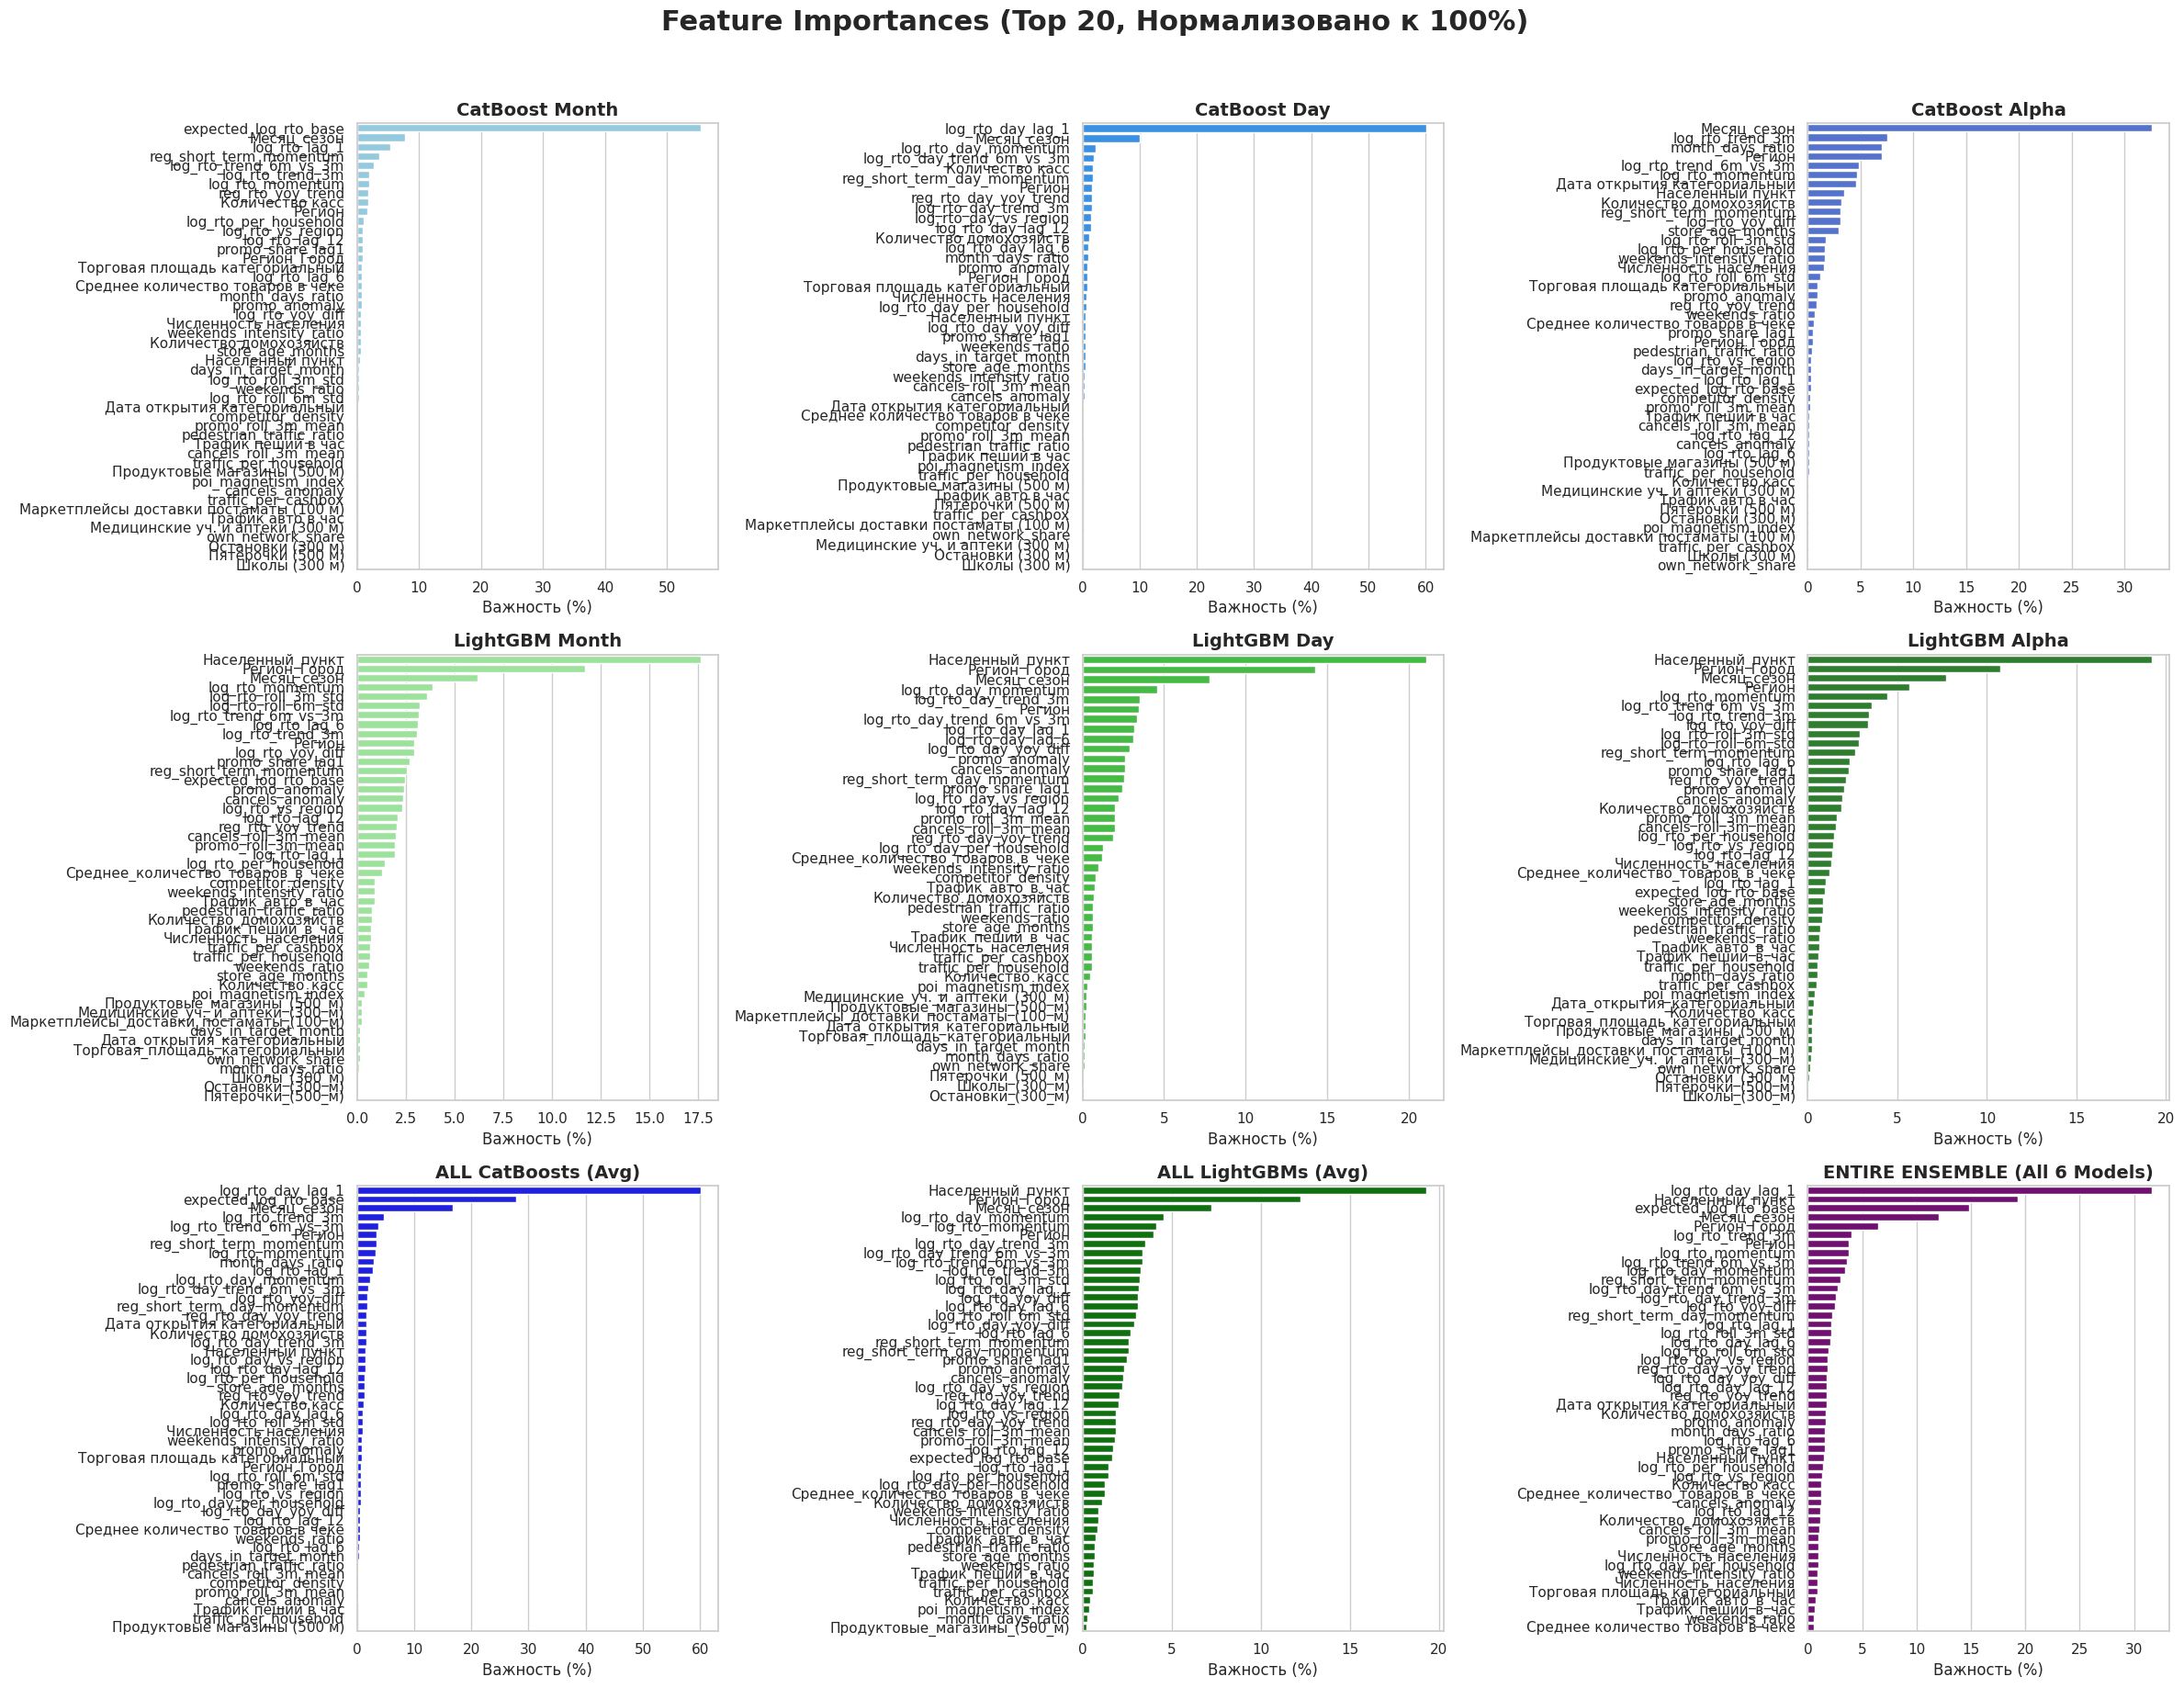


ТОП-10 самых важных признаков для всего ансамбля в целом:


,feature,importance
63,log_rto_day_lag_1,31.645949
48,Населенный_пункт,19.304687
0,expected_log_rto_base,14.794626
1,Месяц_сезон,12.023669
14,Регион_Город,6.504140
5,log_rto_trend_3m,4.013526
9,Регион,3.737102
6,log_rto_momentum,3.733287
4,log_rto_trend_6m_vs_3m,3.557103
64,log_rto_day_momentum,3.441854


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def analyze_feature_importances(stored_cb_m, stored_lgb_m, stored_cb_d, stored_lgb_d, stored_cb_a, stored_lgb_a, top_n=20):
    
    def get_importance(models):
        if not models: return None
        
        features = models[0].feature_names_ if hasattr(models[0], 'feature_names_') else models[0].feature_name_
        importance_sum = np.zeros(len(features))
        
        for m in models:
            if type(m).__name__ == 'CatBoostRegressor':
                imp = m.get_feature_importance()
            else:
                imp = m.feature_importances_
                
            if imp.sum() > 0:
                imp = (imp / imp.sum()) * 100 
            importance_sum += imp
            
        avg_imp = importance_sum / len(models)
        df_imp = pd.DataFrame({'feature': features, 'importance': avg_imp})
        return df_imp.sort_values(by='importance', ascending=False)

    imp_cb_m = get_importance(stored_cb_m)
    imp_lgb_m = get_importance(stored_lgb_m)
    imp_cb_d = get_importance(stored_cb_d)
    imp_lgb_d = get_importance(stored_lgb_d)
    imp_cb_a = get_importance(stored_cb_a)
    imp_lgb_a = get_importance(stored_lgb_a)
    
    def merge_and_avg(dfs):
        merged = pd.concat([df.set_index('feature') for df in dfs], axis=1)
        avg = merged.mean(axis=1).reset_index()
        avg.columns = ['feature', 'importance']
        return avg.sort_values(by='importance', ascending=False)

    imp_all_cb = merge_and_avg([imp_cb_m, imp_cb_d, imp_cb_a])
    imp_all_lgb = merge_and_avg([imp_lgb_m, imp_lgb_d, imp_lgb_a])
    imp_ensemble = merge_and_avg([imp_cb_m, imp_lgb_m, imp_cb_d, imp_lgb_d, imp_cb_a, imp_lgb_a])

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(3, 3, figsize=(24, 18))
    fig.suptitle('Feature Importances (Top 20, Нормализовано к 100%)', fontsize=22, fontweight='bold', y=1.02)
    
    def plot_imp(ax, df, title, color):
        sns.barplot(x='importance', y='feature', data=df.head(top_n), ax=ax, color=color)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Важность (%)')
        ax.set_ylabel('')

    plot_imp(axes[0, 0], imp_cb_m, 'CatBoost Month', 'skyblue')
    plot_imp(axes[0, 1], imp_cb_d, 'CatBoost Day', 'dodgerblue')
    plot_imp(axes[0, 2], imp_cb_a, 'CatBoost Alpha', 'royalblue')

    plot_imp(axes[1, 0], imp_lgb_m, 'LightGBM Month', 'lightgreen')
    plot_imp(axes[1, 1], imp_lgb_d, 'LightGBM Day', 'limegreen')
    plot_imp(axes[1, 2], imp_lgb_a, 'LightGBM Alpha', 'forestgreen')

    plot_imp(axes[2, 0], imp_all_cb, 'ALL CatBoosts (Avg)', 'blue')
    plot_imp(axes[2, 1], imp_all_lgb, 'ALL LightGBMs (Avg)', 'green')
    plot_imp(axes[2, 2], imp_ensemble, 'ENTIRE ENSEMBLE (All 6 Models)', 'purple')

    plt.tight_layout()
    plt.show()
    
    return imp_ensemble

final_importance_df = analyze_feature_importances(
    stored_cb_m=stored_cb_m, 
    stored_lgb_m=stored_lgb_m, 
    stored_cb_d=stored_cb_d, 
    stored_lgb_d=stored_lgb_d, 
    stored_cb_a=stored_cb_a, 
    stored_lgb_a=stored_lgb_a,
    top_n=50
)

print("\nТОП-10 самых важных признаков для всего ансамбля в целом:")
display(final_importance_df.head(10))

In [24]:
def optimize_blend_multipliers(oof_dict, start_mult=0.970, end_mult=1.030, step=0.001):
    """
    Быстрый подбор оптимального множителя для каждого типа бленда
    без переобучения моделей.
    """
    multipliers = np.arange(start_mult, end_mult + step, step)
    
    y_true = oof_dict['y_true']

    pred_month = (oof_dict['cb_m'] + oof_dict['lgb_m']) / 2.0
    pred_day = (oof_dict['cb_d'] + oof_dict['lgb_d']) / 2.0
    pred_alpha = (oof_dict['cb_a'] + oof_dict['lgb_a']) / 2.0
    
    pred_m_d = (oof_dict['cb_m'] + oof_dict['lgb_m'] + oof_dict['cb_d'] + oof_dict['lgb_d']) / 4.0
    pred_m_a = (oof_dict['cb_m'] + oof_dict['lgb_m'] + oof_dict['cb_a'] + oof_dict['lgb_a']) / 4.0
    pred_d_a = (oof_dict['cb_d'] + oof_dict['lgb_d'] + oof_dict['cb_a'] + oof_dict['lgb_a']) / 4.0
    
    pred_all_6 = (oof_dict['cb_m'] + oof_dict['lgb_m'] + oof_dict['cb_d'] + oof_dict['lgb_d'] + oof_dict['cb_a'] + oof_dict['lgb_a']) / 6.0
    
    blends = {
        '1. Month Only (2 models)': pred_month,
        '2. Day Only (2 models)  ': pred_day,
        '3. Alpha Only (2 models)': pred_alpha,
        '4. Month + Day          ': pred_m_d,
        '5. Month + Alpha        ': pred_m_a,
        '6. Day + Alpha          ': pred_d_a,
        '7. ВСЕ 6 Моделей        ': pred_all_6
    }
    
    print(f"="*85)
    print(f"{'Название бленда':<26} | {'Ориг. MAPE':<12} | {'Лучший Множ.':<12} | {'Новый MAPE':<12} | {'Прогресс':<10}")
    print(f"="*85)
    
    best_overall_blend = None
    best_overall_mape = float('inf')
    best_overall_orig_mape = float('inf')
    best_overall_mult = 1.0
    
    for name, pred in blends.items():
        orig_mape = mean_absolute_percentage_error(y_true, np.clip(pred, 0, None)) * 100
        
        best_mape = float('inf')
        best_m = 1.0
        
        for m in multipliers:
            shifted_pred = np.clip(pred * m, 0, None)
            mape = mean_absolute_percentage_error(y_true, shifted_pred) * 100
            
            if mape < best_mape:
                best_mape = mape
                best_m = m
                
        diff = best_mape - orig_mape
        print(f"{name:<26} | {orig_mape:.4f}%    | {best_m:.3f}       | {best_mape:.4f}%    | {diff:+.4f}%")
        
        if best_mape < best_overall_mape:
            best_overall_mape = best_mape
            best_overall_orig_mape = orig_mape
            best_overall_blend = name
            best_overall_mult = best_m

    print(f"="*85)
    print(f"best res: {best_overall_blend}")
    print(f"Оригинальный MAPE: {best_overall_orig_mape:.4f}%")
    print(f"Оптимальный множитель: {best_overall_mult:.3f} -> Итоговый MAPE: {best_overall_mape:.4f}%")
    print(f"="*85)
    
    return best_overall_mult

In [25]:
best_multiplier = optimize_blend_multipliers(oof_dict, start_mult=0.950, end_mult=1.050, step=0.001)

Название бленда            | Ориг. MAPE   | Лучший Множ. | Новый MAPE   | Прогресс  
1. Month Only (2 models)   | 3.9379%    | 0.994       | 3.9031%    | -0.0348%
2. Day Only (2 models)     | 3.8843%    | 0.997       | 3.8780%    | -0.0063%
3. Alpha Only (2 models)   | 4.2373%    | 0.999       | 4.2365%    | -0.0008%
4. Month + Day             | 3.8497%    | 0.996       | 3.8319%    | -0.0178%
5. Month + Alpha           | 3.9561%    | 0.996       | 3.9437%    | -0.0124%
6. Day + Alpha             | 3.9219%    | 0.998       | 3.9178%    | -0.0041%
7. ВСЕ 6 Моделей           | 3.8711%    | 0.997       | 3.8609%    | -0.0102%
best res: 4. Month + Day          
Оригинальный MAPE: 3.8497%
Оптимальный множитель: 0.996 -> Итоговый MAPE: 3.8319%


# Optuna

In [ ]:
import optuna
import numpy as np
import pandas as pd
import sqlite3

def objective(trial, master_df_m, master_df_d, val_cnt, time_ids, cat_features, drop_cols):
    cb_depth_fixed = 6
    lgb_max_depth_fixed = 7
    lgb_min_child_fixed = 70
    lgb_sub_fixed = 1.0

    lgb_leaves = trial.suggest_int('lgb_leaves', 31, 100)
    
    cb_m_lr = trial.suggest_float('cb_m_lr', 0.01, 0.08, log=True)
    cb_d_lr = trial.suggest_float('cb_d_lr', 0.01, 0.08, log=True)
    cb_a_lr = trial.suggest_float('cb_a_lr', 0.01, 0.08, log=True)
    
    lgb_m_lr = trial.suggest_float('lgb_m_lr', 0.01, 0.08, log=True)
    lgb_d_lr = trial.suggest_float('lgb_d_lr', 0.01, 0.08, log=True)
    lgb_a_lr = trial.suggest_float('lgb_a_lr', 0.01, 0.08, log=True)
    
    cb_m_params = {
        'iterations': 5000, 'learning_rate': cb_m_lr, 'depth': cb_depth_fixed,
        'loss_function': 'MAE', 'eval_metric': 'MAE', 'l2_leaf_reg': 5,
        'random_seed': 42, 'od_type': 'Iter', 'od_wait': 500, 'task_type': 'GPU', 'verbose': 0
    }
    
    cb_d_params = {
        'iterations': 5000, 'learning_rate': cb_d_lr, 'depth': cb_depth_fixed,
        'loss_function': 'MAE', 'eval_metric': 'MAE', 'l2_leaf_reg': 5,
        'random_seed': 42, 'od_type': 'Iter', 'od_wait': 500, 'task_type': 'GPU', 'verbose': 0
    }

    cb_a_params = {
        'iterations': 5000, 'learning_rate': cb_a_lr, 'depth': cb_depth_fixed,
        'loss_function': 'MAE', 'eval_metric': 'MAE', 'l2_leaf_reg': 5,
        'random_seed': 42, 'od_type': 'Iter', 'od_wait': 500, 'task_type': 'GPU', 'verbose': 0
    }
    
    lgbm_m_params = {
        'objective': 'regression_l1', 'metric': 'mae',
        'n_estimators': 5000, 'learning_rate': lgb_m_lr, 'num_leaves': lgb_leaves,
        'max_depth': lgb_max_depth_fixed, 'min_child_samples': lgb_min_child_fixed,
        'subsample': lgb_sub_fixed, 'colsample_bytree': 1.0, 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    
    lgbm_d_params = {
        'objective': 'regression_l1', 'metric': 'mae',
        'n_estimators': 5000, 'learning_rate': lgb_d_lr, 'num_leaves': lgb_leaves,
        'max_depth': lgb_max_depth_fixed, 'min_child_samples': lgb_min_child_fixed,
        'subsample': lgb_sub_fixed, 'colsample_bytree': 1.0, 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }

    lgbm_a_params = {
        'objective': 'regression_l1', 'metric': 'mae',
        'n_estimators': 5000, 'learning_rate': lgb_a_lr, 'num_leaves': lgb_leaves,
        'max_depth': lgb_max_depth_fixed, 'min_child_samples': lgb_min_child_fixed,
        'subsample': lgb_sub_fixed, 'colsample_bytree': 1.0, 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }

    stored_cb_m, stored_lgb_m, stored_cb_d, stored_lgb_d, stored_cb_a, stored_lgb_a, scores, oof_dict = run_cv_67model_ensemble(
        master_df_m=master_df_m, master_df_d=master_df_d, val_cnt=val_cnt,
        time_ids=time_ids, cat_features=cat_features, drop_cols=drop_cols,
        cb_m_params=cb_m_params, cb_d_params=cb_d_params, cb_a_params=cb_a_params,
        lgbm_m_params=lgbm_m_params, lgbm_d_params=lgbm_d_params, lgbm_a_params=lgbm_a_params
    )
    
    mean_mape = np.mean(scores)
    
    trial.set_user_attr('cb_m_iter', int(np.mean([m.get_best_iteration() for m in stored_cb_m])))
    trial.set_user_attr('cb_d_iter', int(np.mean([m.get_best_iteration() for m in stored_cb_d])))
    trial.set_user_attr('cb_a_iter', int(np.mean([m.get_best_iteration() for m in stored_cb_a])))
    trial.set_user_attr('lgb_m_iter', int(np.mean([m.best_iteration_ for m in stored_lgb_m])))
    trial.set_user_attr('lgb_d_iter', int(np.mean([m.best_iteration_ for m in stored_lgb_d])))
    trial.set_user_attr('lgb_a_iter', int(np.mean([m.best_iteration_ for m in stored_lgb_a])))
    
    return mean_mape

def optuna_logging_callback(study, trial):
    log_msg = (
        f"Trial {trial.number} | MAPE: {trial.value:.5f}\n"
        f"Params: {trial.params}\n"
        f"Best Iters -> CB_M: {trial.user_attrs.get('cb_m_iter')}, LGB_M: {trial.user_attrs.get('lgb_m_iter')}, "
        f"CB_D: {trial.user_attrs.get('cb_d_iter')}, LGB_D: {trial.user_attrs.get('lgb_d_iter')}, "
        f"CB_A: {trial.user_attrs.get('cb_a_iter')}, LGB_A: {trial.user_attrs.get('lgb_a_iter')}\n"
        f"Best MAPE so far: {study.best_value:.5f}\n"
        f"{'-' * 50}\n"
    )
    with open('optuna_night_logs.txt', 'a') as f:
        f.write(log_msg)
    print(log_msg)

def run_optuna_tuning(master_df_m, master_df_d, val_cnt, time_ids, cat_features, drop_cols, n_trials=30):
    study = optuna.create_study(
        study_name="6model_ensemble_tuning",
        storage="sqlite:///optuna_study.db",
        load_if_exists=True,
        direction="minimize"
    )
    
    func = lambda trial: objective(trial, master_df_m, master_df_d, val_cnt, time_ids, cat_features, drop_cols)
    study.optimize(func, n_trials=n_trials, callbacks=[optuna_logging_callback])
    return study

In [ ]:
N_TRIALS = 30

study = run_optuna_tuning(
    master_df_m=master_df_m, 
    master_df_d=master_df_d, 
    val_cnt=3,               
    time_ids=time_ids,       
    cat_features=cat_features,
    drop_cols=DROP_COLS,      
    n_trials=N_TRIALS
)


print(f"Лучший MAPE: {study.best_value:.5f}")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

print("\nЛучшие итерации:")
best_trial = study.best_trial
print(f"CB_M iter: {best_trial.user_attrs.get('cb_m_iter')}")
print(f"LGB_M iter: {best_trial.user_attrs.get('lgb_m_iter')}")
print(f"CB_D iter: {best_trial.user_attrs.get('cb_d_iter')}")
print(f"LGB_D iter: {best_trial.user_attrs.get('lgb_d_iter')}")
print(f"CB_A iter: {best_trial.user_attrs.get('cb_a_iter')}")
print(f"LGB_A iter: {best_trial.user_attrs.get('lgb_a_iter')}")

In [13]:
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший средний MAPE ансамбля: {study.best_value:.3f}%")
print("\nЛучшие параметры для подстановки:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

print("\nРекомендуемые базовые итерации для финального обучения (среднее по фолдам):")
print(f"    CatBoost Month: {study.best_trial.user_attrs['cb_m_avg_iter']}")
print(f"    LightGBM Month: {study.best_trial.user_attrs['lgb_m_avg_iter']}")
print(f"    CatBoost Day:   {study.best_trial.user_attrs['cb_d_avg_iter']}")
print(f"    LightGBM Day:   {study.best_trial.user_attrs['lgb_d_avg_iter']}")


[I 2026-05-29 19:10:51,434] A new study created in memory with name: no-name-09bc587e-cb9e-4363-940f-48046d781e5e


  0%|          | 0/30 [00:00<?, ?it/s]

Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


[I 2026-05-29 19:26:19,320] Trial 0 finished with value: 3.9609885649582526 and parameters: {'cb_lr': 0.023688639503640783, 'cb_depth': 8, 'cb_l2': 11.247915185359671, 'lgb_lr': 0.03968793330444373, 'lgb_leaves': 40, 'lgb_max_depth': 5, 'lgb_min_child': 24, 'lgb_colsample': 0.9330880728874675, 'lgb_subsample': 0.8005575058716043}. Best is trial 0 with value: 3.9609885649582526.


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric perio

[I 2026-05-29 19:59:25,636] Trial 2 finished with value: 3.9531281810908645 and parameters: {'cb_lr': 0.027036160666620016, 'cb_depth': 5, 'cb_l2': 9.565940526113312, 'lgb_lr': 0.013787764619353767, 'lgb_leaves': 58, 'lgb_max_depth': 7, 'lgb_min_child': 56, 'lgb_colsample': 0.8925879806965068, 'lgb_subsample': 0.5998368910791798}. Best is trial 2 with value: 3.9531281810908645.


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


[W 2026-05-29 20:01:42,446] Trial 3 failed with parameters: {'cb_lr': 0.032676417657817626, 'cb_depth': 6, 'cb_l2': 1.6503057780799681, 'lgb_lr': 0.04050837781329675, 'lgb_leaves': 42, 'lgb_max_depth': 5, 'lgb_min_child': 96, 'lgb_colsample': 0.9828160165372797, 'lgb_subsample': 0.9041986740582306} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_105/2940782916.py", line 97, in objective
    model_lgb_d.fit(X_train_d, y_train_log_day, eval_set=[(X_val_d, y_val_log_day)],
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1398, in fit
    super().fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages

KeyboardInterrupt: 

In [15]:
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший средний MAPE ансамбля: {study.best_value:.3f}%")
print("\nЛучшие параметры для подстановки:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

print("\nРекомендуемые базовые итерации для финального обучения (среднее по фолдам):")
print(f"    CatBoost Month: {study.best_trial.user_attrs['cb_m_avg_iter']}")
print(f"    LightGBM Month: {study.best_trial.user_attrs['lgb_m_avg_iter']}")
print(f"    CatBoost Day:   {study.best_trial.user_attrs['cb_d_avg_iter']}")
print(f"    LightGBM Day:   {study.best_trial.user_attrs['lgb_d_avg_iter']}")

[I 2026-05-29 18:13:43,247] A new study created in memory with name: no-name-c2a1917a-733a-4914-8bcb-f547d84c7feb


  0%|          | 0/30 [00:00<?, ?it/s]

Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


[I 2026-05-29 18:29:03,568] Trial 0 finished with value: 3.9514935592424743 and parameters: {'cb_lr': 0.023688639503640783, 'cb_depth': 8, 'cb_l2': 11.247915185359671, 'lgb_lr': 0.03968793330444373, 'lgb_leaves': 40, 'lgb_max_depth': 5, 'lgb_min_child': 24, 'lgb_colsample': 0.9330880728874675, 'lgb_subsample': 0.8005575058716043}. Best is trial 0 with value: 3.9514935592424743.


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


[I 2026-05-29 18:44:05,454] Trial 1 finished with value: 3.991960052296543 and parameters: {'cb_lr': 0.051059032093947576, 'cb_depth': 4, 'cb_l2': 14.57873793026792, 'lgb_lr': 0.06798962421591129, 'lgb_leaves': 47, 'lgb_max_depth': 6, 'lgb_min_child': 34, 'lgb_colsample': 0.6521211214797689, 'lgb_subsample': 0.762378215816119}. Best is trial 0 with value: 3.9514935592424743.


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


[I 2026-05-29 19:01:10,508] Trial 2 finished with value: 3.953640609387211 and parameters: {'cb_lr': 0.027036160666620016, 'cb_depth': 5, 'cb_l2': 9.565940526113312, 'lgb_lr': 0.013787764619353767, 'lgb_leaves': 58, 'lgb_max_depth': 7, 'lgb_min_child': 56, 'lgb_colsample': 0.8925879806965068, 'lgb_subsample': 0.5998368910791798}. Best is trial 0 with value: 3.9514935592424743.


Default metric period is 5 because MAE is/are not implemented for GPU


: 

# Weighted Sum

In [15]:
from scipy.optimize import minimize

def find_optimal_weights(oof_dict):
    """
    Находит оптимальные веса для ансамбля 4 моделей минимизируя MAPE.
    """
    y_true = oof_dict['y_true']
    preds = np.column_stack([
        oof_dict['cb_m'],
        oof_dict['lgb_m'],
        oof_dict['cb_d'],
        oof_dict['lgb_d']
    ])
    
    def objective_func(weights):
        weighted_preds = np.dot(preds, weights)
        weighted_preds = np.clip(weighted_preds, 0, None)
        return mean_absolute_percentage_error(y_true, weighted_preds)
    
    initial_weights = [0.25, 0.25, 0.25, 0.25]
    
    bounds = [(0, 1)] * 4
    
    constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
    
    print("Запускаю оптимизацию весов...")
    result = minimize(
        objective_func, 
        initial_weights, 
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints
    )
    
    best_weights = result.x
    best_mape = result.fun * 100
    
    print("-" * 40)
    print("ОПТИМАЛЬНЫЕ ВЕСА:")
    print(f"CatBoost Month : {best_weights[0]:.4f}")
    print(f"LightGBM Month : {best_weights[1]:.4f}")
    print(f"CatBoost Day   : {best_weights[2]:.4f}")
    print(f"LightGBM Day   : {best_weights[3]:.4f}")
    print("-" * 40)
    print(f"MAPE со взвешенной суммой: {best_mape:.4f}%")
    
    return best_weights

In [16]:
gp = {'cb_m_lr': 0.05828735182097483, 'cb_m_depth': 5, 
    'cb_m_l2': 6.2796177403914575, 'cb_d_lr': 0.01590642899086447, 
    'cb_d_depth': 6, 'cb_d_l2': 6.658916895122722, 
    'lgb_m_lr': 0.060974841070787, 'lgb_m_leaves': 67, 
    'lgb_m_min_child': 45, 'lgb_m_sub': 0.8478917930582126, 
    'lgb_d_lr': 0.038250926221749824, 'lgb_d_leaves': 61, 
    'lgb_d_min_child': 59, 'lgb_d_sub': 0.6167034995794947}


lgbm_m_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': gp['lgb_m_lr'],
    'n_estimators': 5000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': gp['lgb_m_leaves'],
    'max_depth': -1,
    'min_child_samples': gp['lgb_m_min_child'],
    'subsample': gp['lgb_m_sub'] 
}

lgbm_d_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': gp['lgb_d_lr'],
    'n_estimators': 5000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': gp['lgb_d_leaves'],
    'max_depth': -1,
    'min_child_samples': gp['lgb_d_min_child'],
    'subsample': gp['lgb_d_sub'] 
}


cb_m_params = {
    'iterations': 5000,
    'learning_rate': gp['cb_m_lr'],
    'depth': gp['cb_m_depth'],
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 500,
    'verbose': 500,
    'l2_leaf_reg': gp['cb_m_l2'],
    'task_type': 'GPU'
}

cb_d_params = {
    'iterations': 5000,
    'learning_rate': gp['cb_d_lr'],
    'depth': gp['cb_d_depth'],
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 500,
    'verbose': 500,
    'l2_leaf_reg': gp['cb_d_l2'],
    'task_type': 'GPU'
}

models_cb_m, models_lgb_m, models_cb_d, models_lgb_d, scores_ensemble, oof_dict = run_cv_4model_ensemble(
    master_df_m=master_df_m,
    master_df_d=master_df_d,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_m_params=cb_m_params, 
    cb_d_params=cb_d_params, 
    lgbm_m_params=lgbm_m_params, 
    lgbm_d_params=lgbm_d_params
)

best_weights = find_optimal_weights(oof_dict)

=== Валидация на месяце: 202411 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 3.836% (best iter: 819) | LGBM: 3.749% (best iter: 2046)
MAPE Day-models   -> CB: 3.717% (best iter: 353) | LGBM: 3.581% (best iter: 4986)
--> ans MAPE: 3.477%

=== Валидация на месяце: 202412 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 4.518% (best iter: 212) | LGBM: 3.823% (best iter: 4749)
MAPE Day-models   -> CB: 3.772% (best iter: 2161) | LGBM: 3.774% (best iter: 4994)
--> ans MAPE: 3.712%

=== Валидация на месяце: 202501 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 5.191% (best iter: 795) | LGBM: 4.253% (best iter: 4974)
MAPE Day-models   -> CB: 4.086% (best iter: 1674) | LGBM: 4.036% (best iter: 4968)
--> ans MAPE: 3.929%

=== Валидация на месяце: 202502 ===


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


MAPE Month-models -> CB: 4.339% (best iter: 582) | LGBM: 4.744% (best iter: 4994)
MAPE Day-models   -> CB: 4.346% (best iter: 948) | LGBM: 4.336% (best iter: 4999)
--> ans MAPE: 4.209%

Средний MAPE ансамбля по фолдам (простое среднее): 3.832%
Запускаю оптимизацию весов...
----------------------------------------
ОПТИМАЛЬНЫЕ ВЕСА:
CatBoost Month : 0.0991
LightGBM Month : 0.1273
CatBoost Day   : 0.4086
LightGBM Day   : 0.3651
----------------------------------------
MAPE со взвешенной суммой: 3.8003%


In [17]:
# === Валидация на месяце: 202411 ===
# MAPE Month-models -> CB: 3.979% (best iter: 1009) | LGBM: 3.749% (best iter: 2046)
# MAPE Day-models   -> CB: 3.700% (best iter: 4979) | LGBM: 3.582% (best iter: 3961)
# --> ans MAPE: 3.569%

# === Валидация на месяце: 202412 ===
# MAPE Month-models -> CB: 3.968% (best iter: 4965) | LGBM: 3.826% (best iter: 3996)
# MAPE Day-models   -> CB: 4.116% (best iter: 4999) | LGBM: 3.783% (best iter: 3985)
# --> ans MAPE: 3.731%

# === Валидация на месяце: 202501 ===
# MAPE Month-models -> CB: 4.224% (best iter: 3581) | LGBM: 4.257% (best iter: 3835)
# MAPE Day-models   -> CB: 4.165% (best iter: 4994) | LGBM: 4.046% (best iter: 3997)
# --> ans MAPE: 3.875%

# === Валидация на месяце: 202502 ===
# MAPE Month-models -> CB: 4.420% (best iter: 282) | LGBM: 4.747% (best iter: 3996)
# MAPE Day-models   -> CB: 4.322% (best iter: 4996) | LGBM: 4.356% (best iter: 3979)
# --> ans MAPE: 4.184%

# ==================================================
# Средний MAPE ансамбля по фолдам: 3.840%
# iter:
#  -> CatBoost Month: 2459
#  -> LightGBM Month: 3468
#  -> CatBoost Day:   4992
#  -> LightGBM Day:   3980
# ==================================================

# Submit

Обучаем финальный CatBoost (Month)...
0:	learn: 0.4496289	total: 30.4ms	remaining: 30.3s
500:	learn: 0.0905986	total: 12.4s	remaining: 12.4s
999:	learn: 0.0879809	total: 25.1s	remaining: 0us
Обучаем финальный LightGBM (Month)...

Обучаем финальный CatBoost (Day)...
0:	learn: 0.4648783	total: 38.7ms	remaining: 1m 9s
500:	learn: 0.0974650	total: 15.1s	remaining: 39.1s
1000:	learn: 0.0920505	total: 30.4s	remaining: 24.3s
1500:	learn: 0.0900892	total: 45.8s	remaining: 9.11s
1799:	learn: 0.0893091	total: 55s	remaining: 0us
Обучаем финальный LightGBM (Day)...

Генерируем признаки для теста: 2025-03...
Собираем прогнозы...
Считаем финальный ансамбль с оптимальными весами...
Готово! Файл submission_final_checked.csv успешно сгенерирован.

--- СТАТИСТИКА ПРЕДСКАЗАНИЙ ---


,new_id,rto
count,18657.000000,1.865700e+04
mean,10881.244680,1.039472e+08
std,6265.465758,5.510178e+07
min,0.000000,1.655759e+07
25%,5455.000000,6.665362e+07
50%,10893.000000,8.867934e+07
75%,16308.000000,1.236585e+08
max,21745.000000,4.470214e+08



--- ВИЗУАЛЬНЫЙ КОНТРОЛЬ ПРЕДСКАЗАНИЙ ---


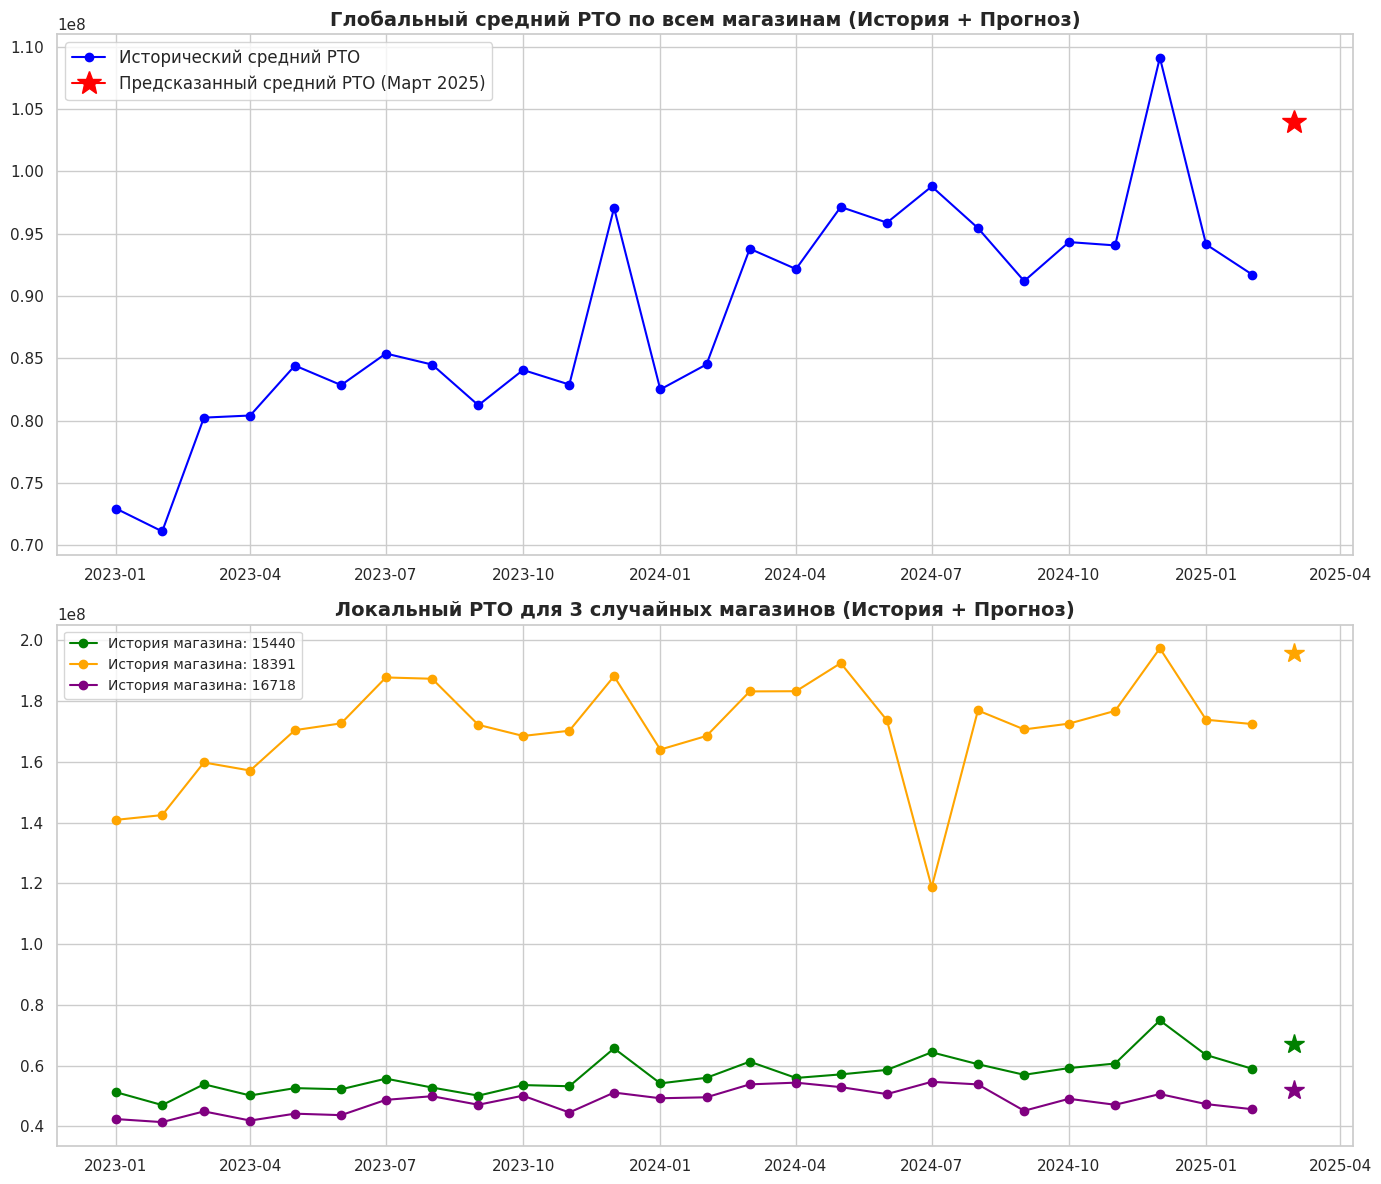

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

gp = {
    'cb_m_lr': 0.05828735182097483, 'cb_m_depth': 5, 'cb_m_l2': 6.2796177403914575, 
    'cb_d_lr': 0.01590642899086447, 'cb_d_depth': 6, 'cb_d_l2': 6.658916895122722, 
    'lgb_m_lr': 0.060974841070787, 'lgb_m_leaves': 67, 'lgb_m_min_child': 45, 'lgb_m_sub': 0.8478917930582126, 
    'lgb_d_lr': 0.038250926221749824, 'lgb_d_leaves': 61, 'lgb_d_min_child': 59, 'lgb_d_sub': 0.6167034995794947
}

w_cb_m = 0.0991
w_lgb_m = 0.1273
w_cb_d = 0.4086
w_lgb_d = 0.3651

lgbm_m_params = {
    'objective': 'regression_l1', 'metric': 'mae', 'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    'learning_rate': gp['lgb_m_lr'], 'num_leaves': gp['lgb_m_leaves'], 'max_depth': -1,
    'min_child_samples': gp['lgb_m_min_child'], 'subsample': gp['lgb_m_sub'], 'colsample_bytree': 1.0,
    'n_estimators': 4610
}

lgbm_d_params = {
    'objective': 'regression_l1', 'metric': 'mae', 'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    'learning_rate': gp['lgb_d_lr'], 'num_leaves': gp['lgb_d_leaves'], 'max_depth': -1,
    'min_child_samples': gp['lgb_d_min_child'], 'subsample': gp['lgb_d_sub'], 'colsample_bytree': 1.0,
    'n_estimators': 5485
}

cb_m_params = {
    'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'random_seed': 42, 'verbose': 500, 'task_type': 'GPU',
    'learning_rate': gp['cb_m_lr'], 'depth': gp['cb_m_depth'], 'l2_leaf_reg': gp['cb_m_l2'],
    'iterations': 1000
}

cb_d_params = {
    'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'random_seed': 42, 'verbose': 500, 'task_type': 'GPU',
    'learning_rate': gp['cb_d_lr'], 'depth': gp['cb_d_depth'], 'l2_leaf_reg': gp['cb_d_l2'],
    'iterations': 1800
}

DROP_COLS_MONTH = DROP_COLS + ['days_in_target_month'] 
DROP_COLS_DAY = DROP_COLS

X_train_m = master_df_m.drop(columns=DROP_COLS_MONTH).copy()
X_train_d = master_df_d.drop(columns=DROP_COLS_DAY).copy()

for col in cat_features:
    X_train_m[col] = X_train_m[col].astype(str).astype('category')
    X_train_d[col] = X_train_d[col].astype(str).astype('category')

y_train_month_log = np.log1p(master_df_m['РТО'])
y_train_day_log = np.log1p(master_df_d['РТО'] / master_df_d['days_in_target_month'])

print("Обучаем финальный CatBoost (Month)...")
pool_train_m = Pool(X_train_m, y_train_month_log, cat_features=cat_features)
final_cb_m = CatBoostRegressor(**cb_m_params)
final_cb_m.fit(pool_train_m)

print("Обучаем финальный LightGBM (Month)...")
final_lgb_m = lgb.LGBMRegressor(**lgbm_m_params)
final_lgb_m.fit(X_train_m, y_train_month_log, categorical_feature=cat_features)

print("\nОбучаем финальный CatBoost (Day)...")
pool_train_d = Pool(X_train_d, y_train_day_log, cat_features=cat_features)
final_cb_d = CatBoostRegressor(**cb_d_params)
final_cb_d.fit(pool_train_d)

print("Обучаем финальный LightGBM (Day)...")
final_lgb_d = lgb.LGBMRegressor(**lgbm_d_params)
final_lgb_d.fit(X_train_d, y_train_day_log, categorical_feature=cat_features)

target_year = 2025 
target_month = 3   
print(f"\nГенерируем признаки для теста: {target_year}-{target_month:02d}...")

test_df_m = create_features_for_month(df, target_year, target_month)
test_df_d = create_features_for_day(df, target_year, target_month)

for col in cat_features:
    test_df_m[col] = test_df_m[col].fillna('Missing').astype(str).astype('category')
    test_df_d[col] = test_df_d[col].fillna('Missing').astype(str).astype('category')

submit_ids = test_df_m['new_id']

X_test_m = test_df_m.drop(columns=DROP_COLS_MONTH, errors='ignore')[X_train_m.columns]
X_test_d = test_df_d.drop(columns=DROP_COLS_DAY, errors='ignore')[X_train_d.columns]

print("Собираем прогнозы...")
preds_raw_cb_m = np.expm1(final_cb_m.predict(X_test_m))
preds_raw_lgb_m = np.expm1(final_lgb_m.predict(X_test_m))

days_in_march = test_df_d['days_in_target_month']
preds_raw_cb_d = np.expm1(final_cb_d.predict(X_test_d)) * days_in_march
preds_raw_lgb_d = np.expm1(final_lgb_d.predict(X_test_d)) * days_in_march

print("Считаем финальный ансамбль с оптимальными весами...")
final_preds_raw = (
    preds_raw_cb_m * w_cb_m +
    preds_raw_lgb_m * w_lgb_m +
    preds_raw_cb_d * w_cb_d +
    preds_raw_lgb_d * w_lgb_d
)
final_preds_raw = (
    preds_raw_cb_m +
    preds_raw_lgb_m  +
    preds_raw_cb_d  +
    preds_raw_lgb_d 
)/4
final_preds_raw = np.clip(final_preds_raw, 0, None)

submission = pd.DataFrame({
    'new_id': submit_ids,
    'rto': final_preds_raw
})

filename = 'submission_final_checked.csv'
submission.to_csv(filename, index=False)
print(f"Готово! Файл {filename} успешно сгенерирован.")

print("\n--- СТАТИСТИКА ПРЕДСКАЗАНИЙ")
display(submission.describe())

print("\n--- ВИЗУАЛЬНЫЙ КОНТРОЛЬ ПРЕДСКАЗАНИЙ")

hist_agg = df.groupby(['Год', 'Месяц'])['РТО'].mean().reset_index()
hist_agg['date'] = pd.to_datetime(hist_agg['Год'].astype(str) + '-' + hist_agg['Месяц'].astype(str).str.zfill(2) + '-01')
hist_agg = hist_agg.sort_values('date')

pred_mean = submission['rto'].mean()
pred_date = pd.to_datetime(f"{target_year}-{target_month:02d}-01")

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].plot(hist_agg['date'], hist_agg['РТО'], marker='o', label='Исторический средний РТО', color='blue')
axes[0].plot(pred_date, pred_mean, marker='*', markersize=18, color='red', label='Предсказанный средний РТО (Март 2025)')
axes[0].set_title('Глобальный средний РТО по всем магазинам (История + Прогноз)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True)

sample_ids = submission['new_id'].sample(3, random_state=42).tolist()
colors = ['green', 'orange', 'purple']

for i, sid in enumerate(sample_ids):
    s_hist = df[df['new_id'] == sid].sort_values(['Год', 'Месяц'])
    s_hist['date'] = pd.to_datetime(s_hist['Год'].astype(str) + '-' + s_hist['Месяц'].astype(str).str.zfill(2) + '-01')
    s_pred = submission[submission['new_id'] == sid]['rto'].values[0]
    
    axes[1].plot(s_hist['date'], s_hist['РТО'], marker='o', label=f'История магазина: {sid}', color=colors[i])
    axes[1].plot(pred_date, s_pred, marker='*', markersize=15, color=colors[i])

axes[1].set_title('Локальный РТО для 3 случайных магазинов (История + Прогноз)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Feature Imp

--- Визуализация индивидуальных моделей ---


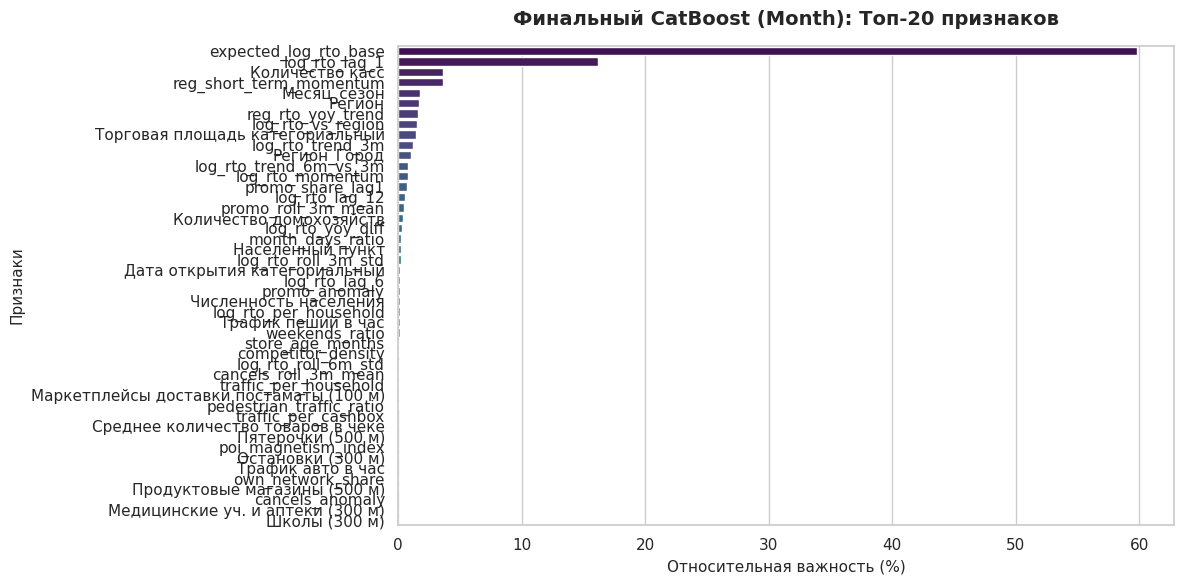

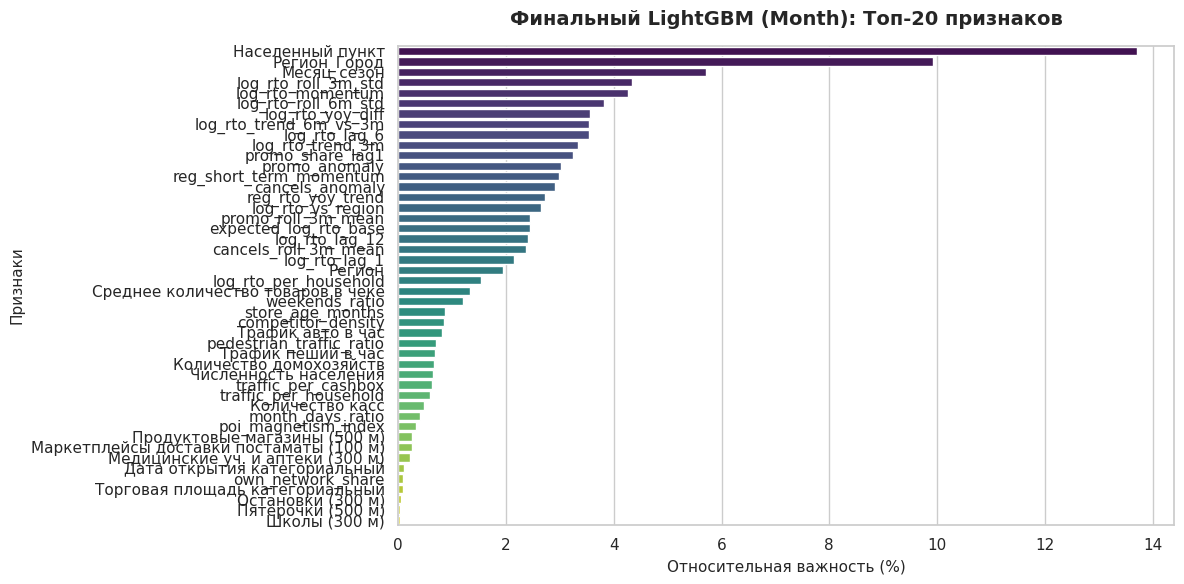

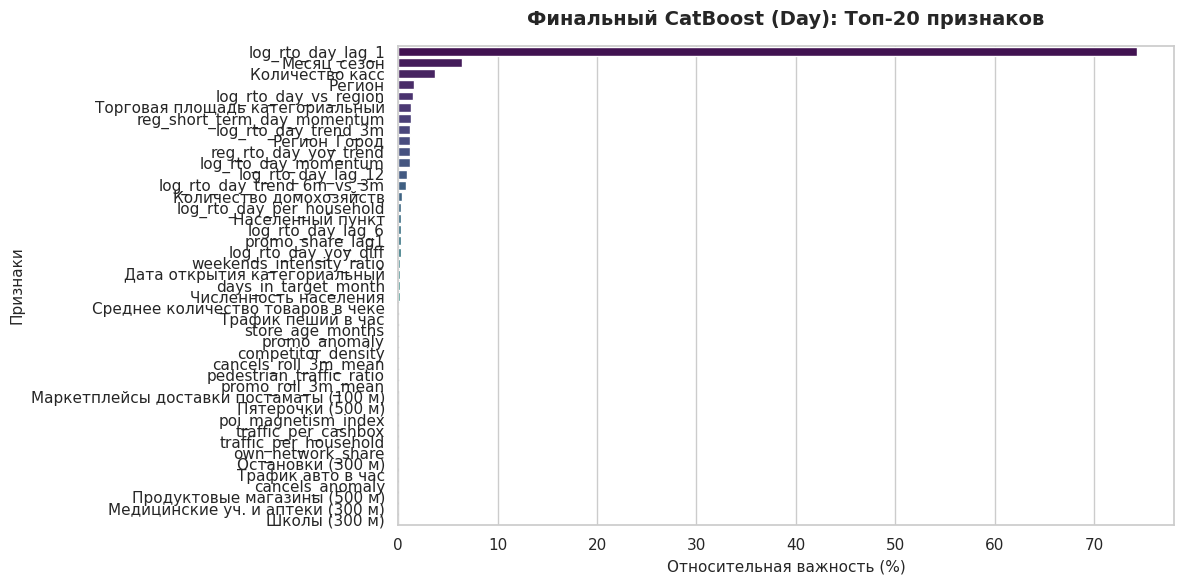

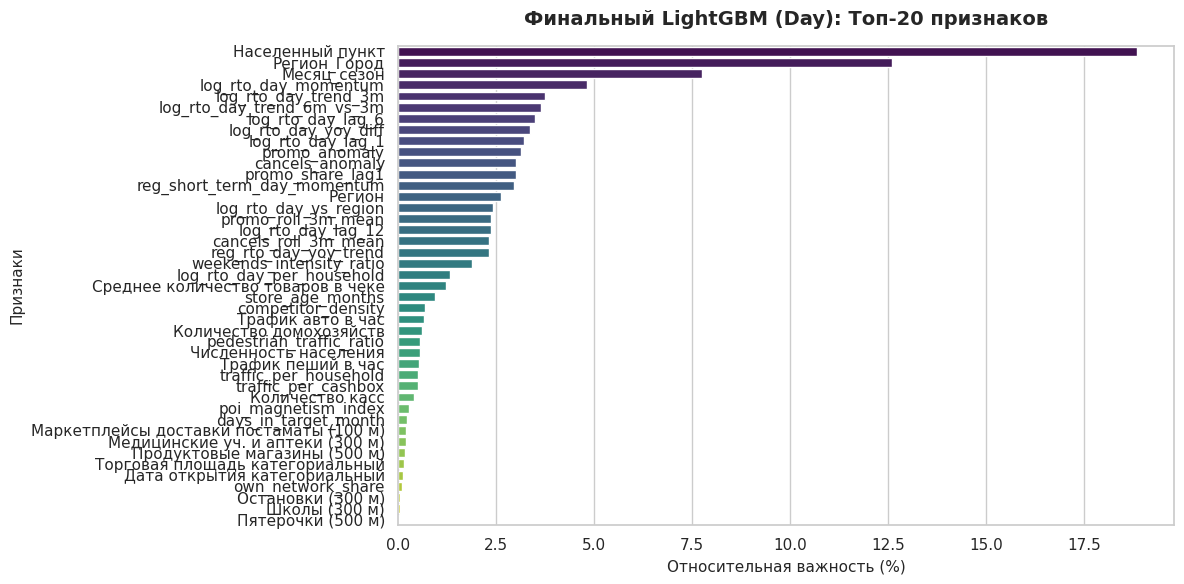


--- Визуализация совместной важности по типу таргета ---


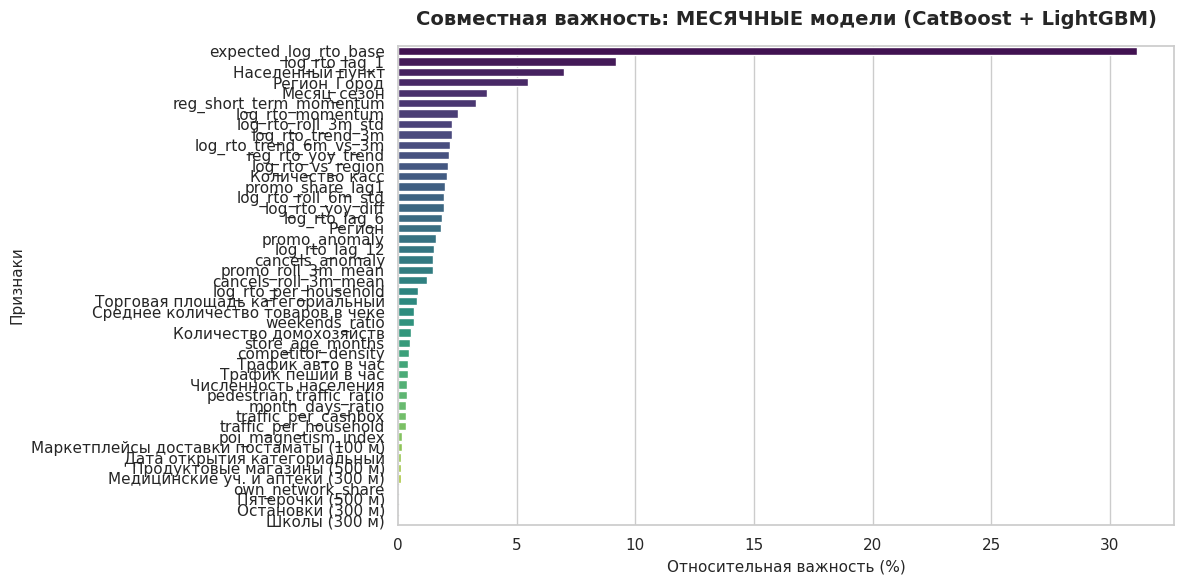

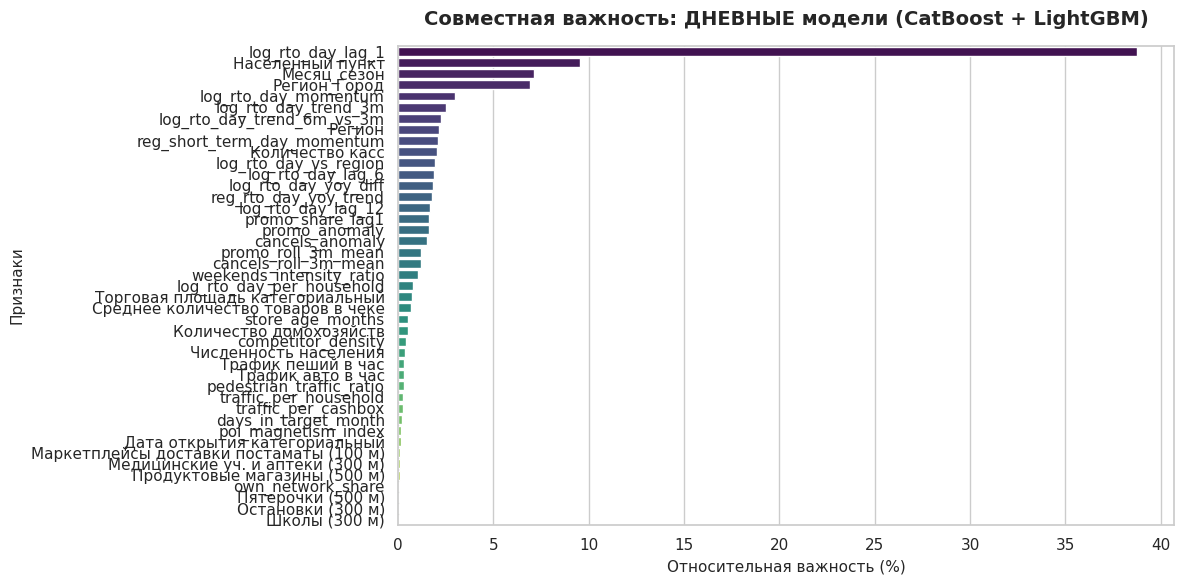


--- Визуализация совместной важности по библиотекам ---


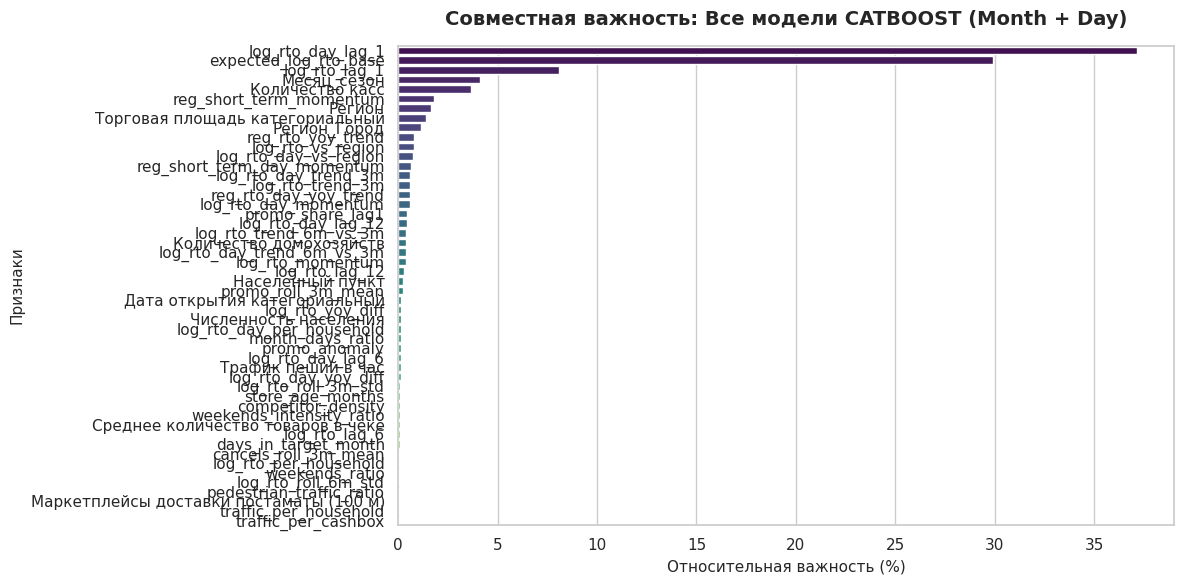

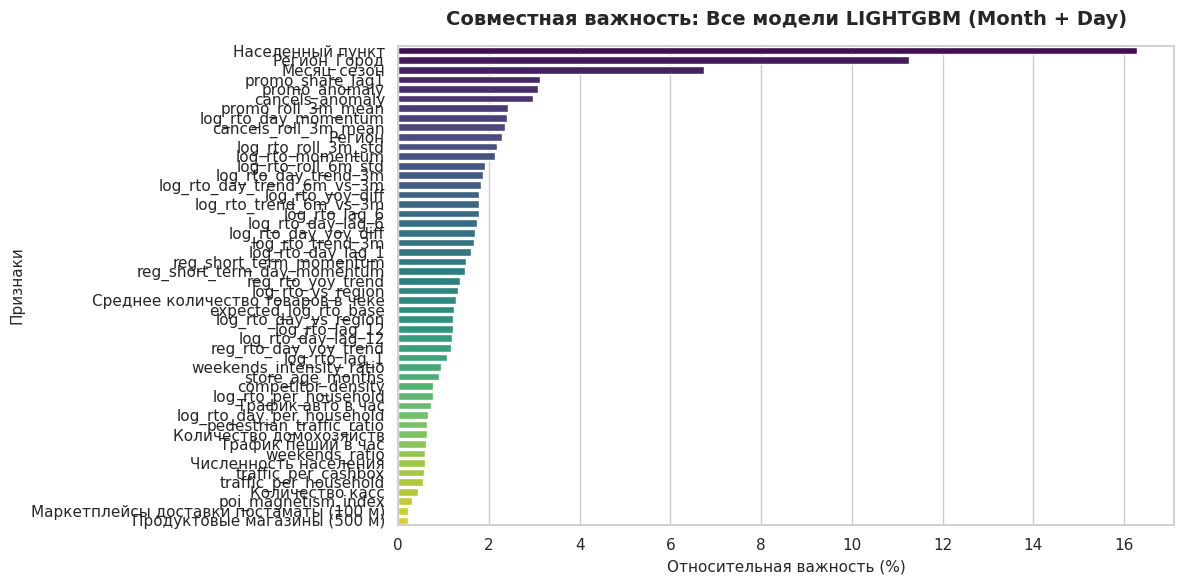

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

features_m = list(X_train_m.columns)
features_d = list(X_train_d.columns)

def get_normalized_importance(importance_values, feature_names):
    imp_series = pd.Series(importance_values, index=feature_names)
    total_importance = imp_series.sum()
    if total_importance > 0:
        imp_series = (imp_series / total_importance) * 100
    return imp_series

def plot_importance(importance_series, title, top_n=50):
    df = importance_series.sort_values(ascending=False).head(top_n).reset_index()
    df.columns = ['Признак', 'Важность (%)']
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Важность (%)', y='Признак', data=df, palette='viridis')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Относительная важность (%)', fontsize=11)
    plt.ylabel('Признаки', fontsize=11)
    plt.tight_layout()
    plt.show()

imp_cb_m = get_normalized_importance(final_cb_m.get_feature_importance(), features_m)
imp_lgb_m = get_normalized_importance(final_lgb_m.feature_importances_, features_m)

imp_cb_d = get_normalized_importance(final_cb_d.get_feature_importance(), features_d)
imp_lgb_d = get_normalized_importance(final_lgb_d.feature_importances_, features_d)

print("--- Визуализация индивидуальных моделей")
plot_importance(imp_cb_m, "Финальный CatBoost (Month): Топ-20 признаков")
plot_importance(imp_lgb_m, "Финальный LightGBM (Month): Топ-20 признаков")
plot_importance(imp_cb_d, "Финальный CatBoost (Day): Топ-20 признаков")
plot_importance(imp_lgb_d, "Финальный LightGBM (Day): Топ-20 признаков")

print("\n" + "="*50 + "\n--- Визуализация совместной важности по типу таргета")

imp_month_combined = (imp_cb_m + imp_lgb_m) / 2.0
plot_importance(imp_month_combined, "Совместная важность: МЕСЯЧНЫЕ модели (CatBoost + LightGBM)")

imp_day_combined = (imp_cb_d + imp_lgb_d) / 2.0
plot_importance(imp_day_combined, "Совместная важность: ДНЕВНЫЕ модели (CatBoost + LightGBM)")

print("\n" + "="*50 + "\n--- Визуализация совместной важности по библиотекам")

imp_all_catboost = imp_cb_m.add(imp_cb_d, fill_value=0) / 2.0
plot_importance(imp_all_catboost, "Совместная важность: Все модели CATBOOST (Month + Day)")

imp_all_lightgbm = imp_lgb_m.add(imp_lgb_d, fill_value=0) / 2.0
plot_importance(imp_all_lightgbm, "Совместная важность: Все модели LIGHTGBM (Month + Day)")